# Fire Simulation Analysis by Management Zone

This notebook analyzes and simulates forest fire behavior across different fire management zones in Ontario, Canada. Using data from the National Fire Database (NFDB) and historical fire management zones, we compare fire characteristics and model future fire scenarios using compound Poisson processes.

## Objectives

1. **Data Analysis**: Examine fire size distributions and occurrence patterns across intensive and extensive management zones
2. **Statistical Modeling**: Fit probabilistic models to fire size distributions (exponential, Weibull, Pareto) and fire count processes (Cox process)
3. **Simulation**: Generate synthetic fire scenarios using both:
   - Cox-Poisson processes (time-varying intensity)
   - Constant intensity Poisson processes
4. **Temporal Analysis**: Investigate trends in fire size and frequency over time using smoothing techniques
5. **Model Validation**: Compare simulated fire distributions with observed historical data

## Key Methods

- **Fire Size Modeling**: Three-parameter distributions fitted to historical fire size data
- **Fire Count Modeling**: Cox process with gamma-distributed intensity parameter
- **Kernel Density Estimation**: For comparing observed vs. simulated fire area distributions
- **LOWESS Smoothing**: For identifying temporal trends in fire characteristics

## Data Sources

- **NFDB Point Data**: Historical fire records with location, year, and burned area
- **Fire Management Zones**: Shapefile defining intensive vs. extensive management areas in Ontario

The analysis provides insights into fire behavior patterns and validates stochastic models for predicting future fire scenarios in different management contexts.

## Import Data

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from compound_poisson_fire_model.simulation_helper import get_fire_data, fit_fire_size_distribution, fit_cox_process,\
    generate_samples, generate_fire_area
from compound_poisson_fire_model.plotting_helper import plot_fire_size_distribution, plot_fire_count_distribution
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KernelDensity


all_fires, intensive, extensive = get_fire_data(True, '../data/nfdb/NFDB_point_20250519.shp', '../data/historical_fire_zones/Historical_Fire_Management_Zones.shp' )


c:\Users\LiW\AppData\Local\anaconda3\envs\poisson_fire\Lib\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


## Modeling Fire Sizes

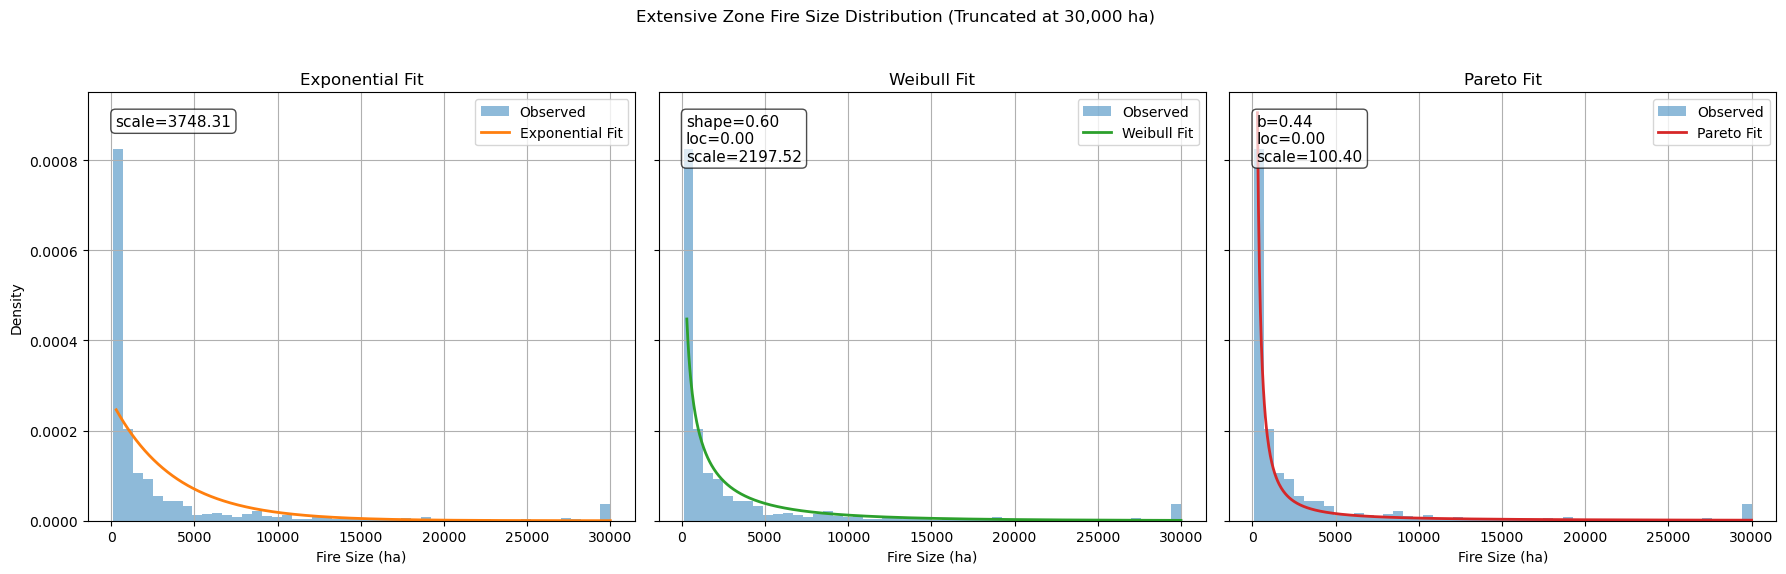

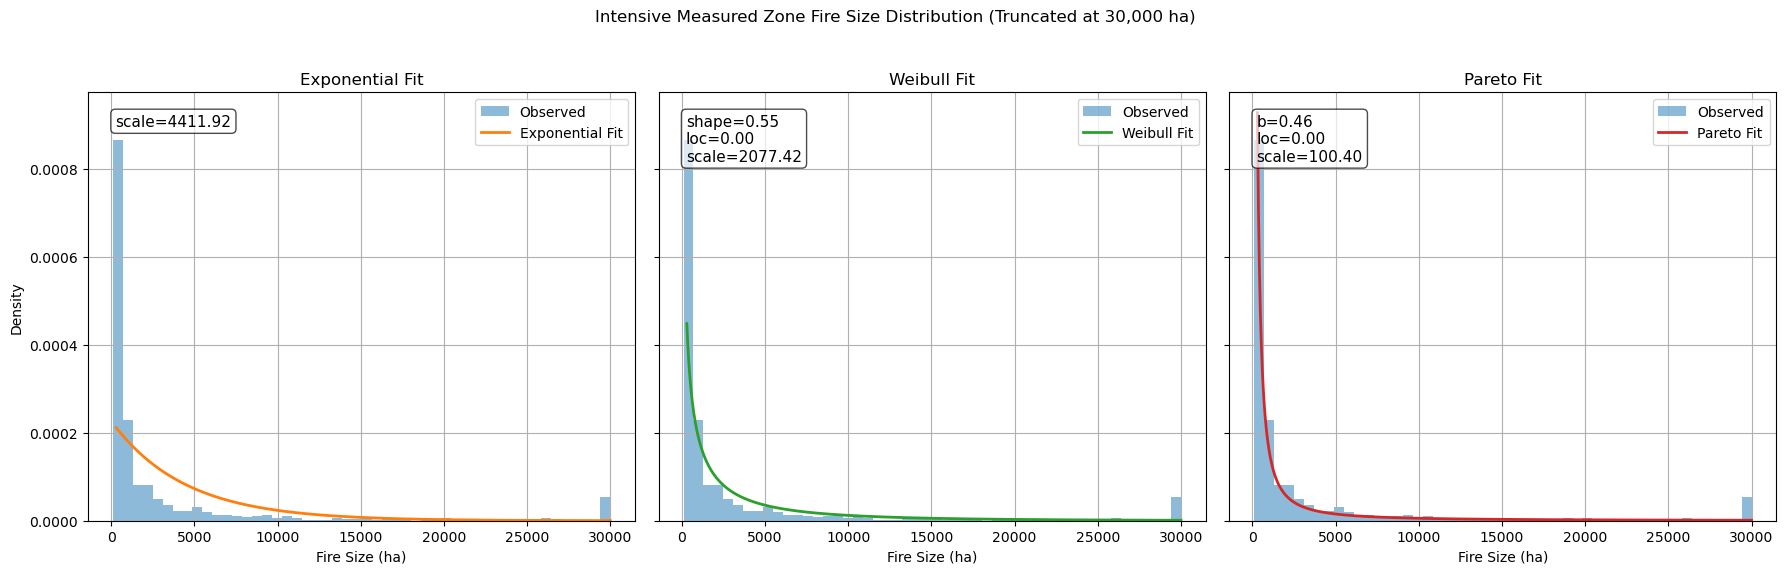

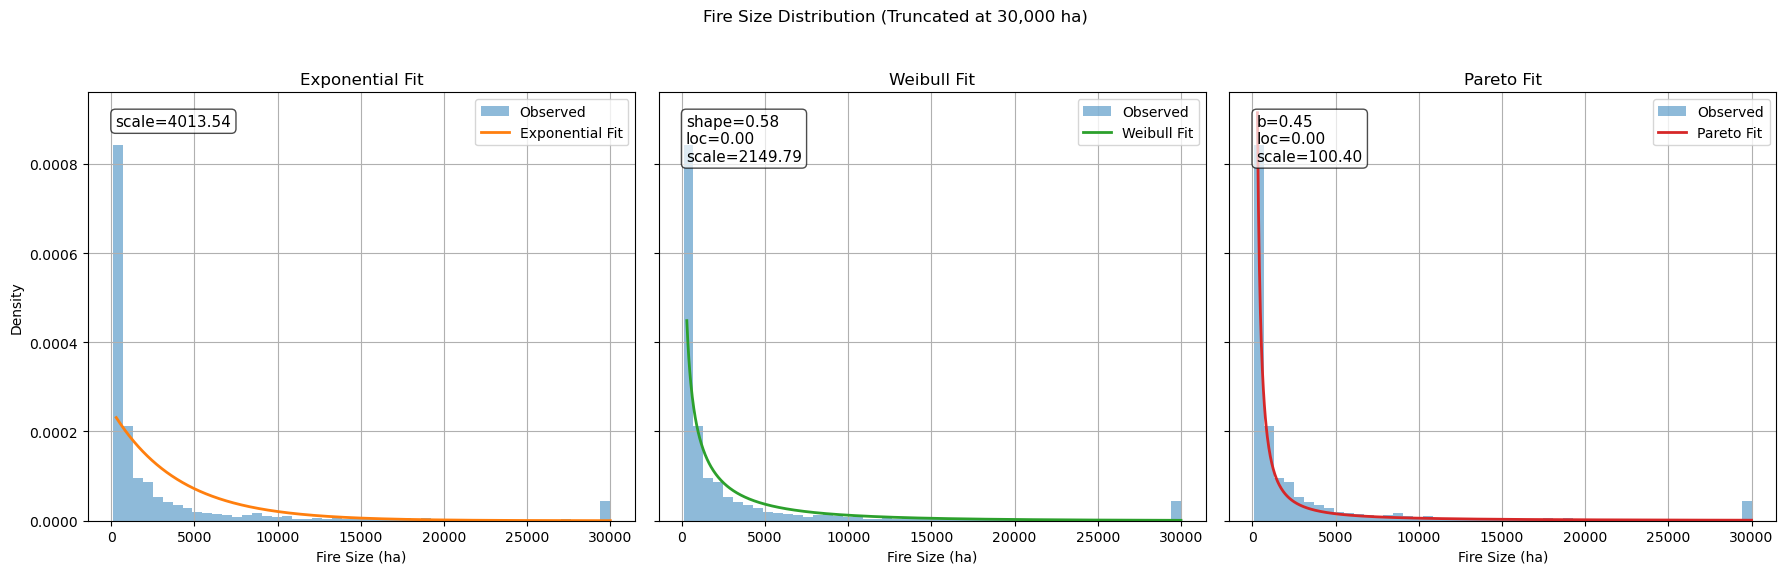

In [23]:
# get parameters for fire size distribution
fire_size_params = fit_fire_size_distribution(extensive['SIZE_HA'])

plot_fire_size_distribution(extensive['SIZE_HA'], 
                            fire_size_params, 
                            upper_limit=30000, 
                            title='Extensive Zone Fire Size Distribution (Truncated at 30,000 ha)')

fire_size_params = fit_fire_size_distribution(intensive['SIZE_HA'])

plot_fire_size_distribution(intensive['SIZE_HA'], 
                            fire_size_params, 
                            upper_limit=30000, 
                            title='Intensive Measured Zone Fire Size Distribution (Truncated at 30,000 ha)')

fire_size_params = fit_fire_size_distribution(all_fires['SIZE_HA'])

plot_fire_size_distribution(all_fires['SIZE_HA'], 
                            fire_size_params, 
                            upper_limit=30000, 
                            title='Fire Size Distribution (Truncated at 30,000 ha)')

In [ ]:
    fire_size_params

{'exponential': np.float64(4013.541733667122),
 'weibull': (np.float64(0.5800951610427723), 0, np.float64(2149.790226628532)),
 'pareto': (np.float64(0.4479115691489905), 0, np.float64(100.400001526))}

# Modeling Fire Counts

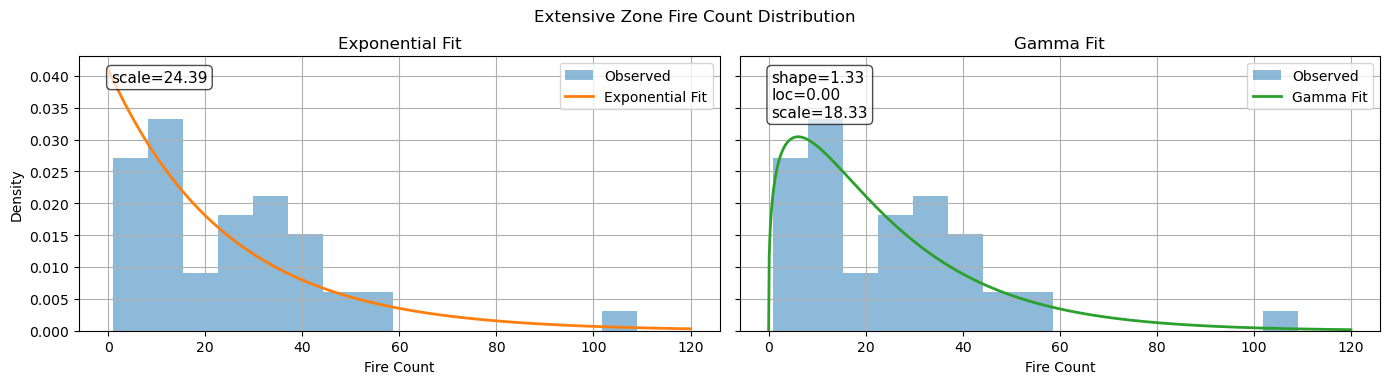

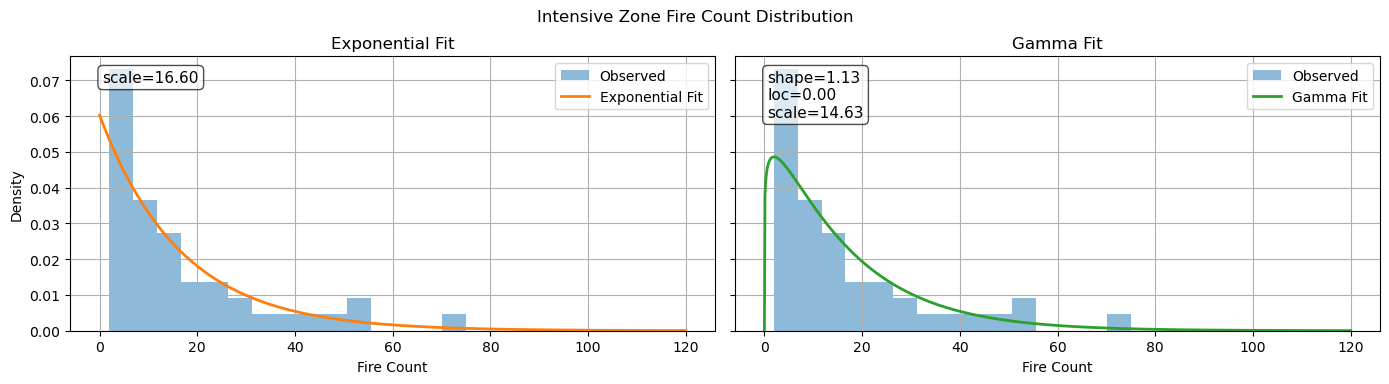

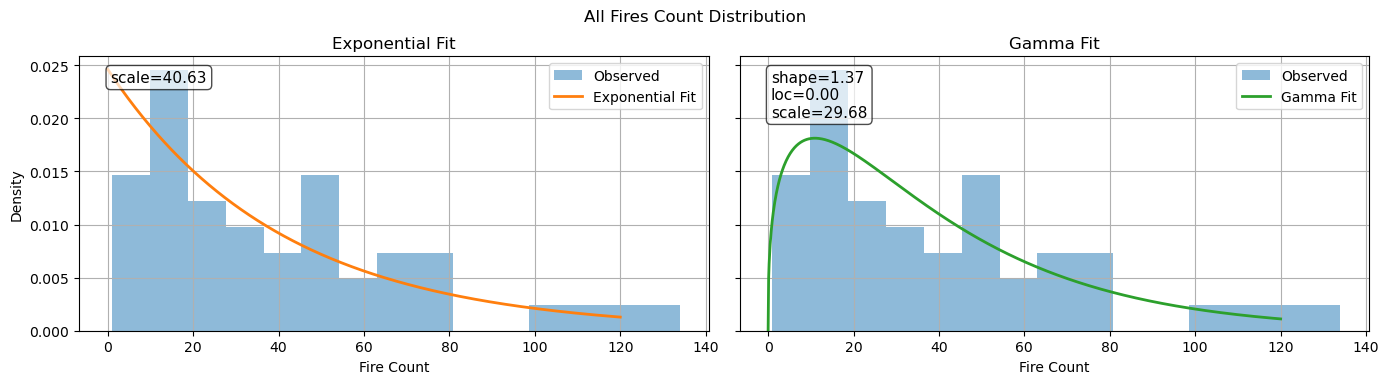

In [6]:
# group by year and get the count of fires
fire_counts_extensive = extensive.groupby('YEAR')['SIZE_HA'].count()
fire_counts_intensive = intensive.groupby('YEAR')['SIZE_HA'].count()
fire_counts_all = all_fires.groupby('YEAR')['SIZE_HA'].count()

# get parameters for Cox process
cox_params = fit_cox_process(fire_counts_extensive)

# plot fire count distribution
plot_fire_count_distribution(fire_counts_extensive, cox_params, title='Extensive Zone Fire Count Distribution')

# get parameters for Cox process for intensive zone
cox_params_intensive = fit_cox_process(fire_counts_intensive)

# plot fire count distribution for intensive zone
plot_fire_count_distribution(fire_counts_intensive, cox_params_intensive, title='Intensive Zone Fire Count Distribution')

# get parameters for Cox process for all fires
cox_params_all = fit_cox_process(fire_counts_all)

# plot fire count distribution for all fires
plot_fire_count_distribution(fire_counts_all, cox_params_all, title='All Fires Count Distribution')

In [30]:
def bootstrap_ci(data, fit_func, n_boot=1000, ci=0.95, random_state=None):
    rng = np.random.default_rng(random_state)
    param_samples = []
    for _ in range(n_boot):
        sample = rng.choice(data, size=len(data), replace=True)
        fit = fit_func(sample)
        # Flatten all parameter values into a list for each bootstrap
        flat_params = []
        for v in fit.values():
            if isinstance(v, tuple):
                flat_params.extend(v)
            else:
                flat_params.append(v)
        param_samples.append(flat_params)
    param_samples = np.array(param_samples)
    lower = np.percentile(param_samples, (1-ci)/2*100, axis=0)
    upper = np.percentile(param_samples, (1+(ci))/2*100, axis=0)
    return np.round(lower, 2), np.round(upper, 2)

lower, upper = bootstrap_ci(all_fires['SIZE_HA'], fit_fire_size_distribution, n_boot=1000, ci=0.95)
lower,upper

(array([3.47857e+03, 5.60000e-01, 0.00000e+00, 1.97513e+03, 4.40000e-01,
        0.00000e+00, 1.00400e+02]),
 array([4.56097e+03, 6.00000e-01, 0.00000e+00, 2.32762e+03, 4.60000e-01,
        0.00000e+00, 1.01200e+02]))

In [31]:
# put lower and upper into df
ci_df = pd.DataFrame({
    "lower": lower,
    "upper": upper
})

# transpose
ci_df = ci_df.T
ci_df

,0,1,2,3,4,5,6
lower,3478.57,0.56,0.0,1975.13,0.44,0.0,100.4
upper,4560.97,0.60,0.0,2327.62,0.46,0.0,101.2


In [9]:
# get the confidence interval with normal approximation for fire_counts_extensive parameters for both the exponential and gamma fit
import scipy.stats as stats

n_extensive = len(fire_counts_extensive)
exp_params_ext = stats.expon.fit(fire_counts_extensive)
gamma_params_ext = stats.gamma.fit(fire_counts_extensive)
# Normal approx CI
exp_loc_ext, exp_scale_ext = exp_params_ext
se_exp_scale_ext = exp_scale_ext / np.sqrt(n_extensive)
z_ext = stats.norm.ppf(0.975)
exp_scale_ci_ext = (exp_scale_ext - z_ext * se_exp_scale_ext, exp_scale_ext + z_ext * se_exp_scale_ext)
gamma_a_ext, gamma_loc_ext, gamma_scale_ext = gamma_params_ext
se_gamma_a_ext = gamma_a_ext / np.sqrt(n_extensive)
se_gamma_scale_ext = gamma_scale_ext / np.sqrt(n_extensive)
gamma_a_ci_ext = (gamma_a_ext - z_ext * se_gamma_a_ext, gamma_a_ext + z_ext * se_gamma_a_ext)
gamma_scale_ci_ext = (gamma_scale_ext - z_ext * se_gamma_scale_ext, gamma_scale_ext + z_ext * se_gamma_scale_ext)

# print everything out in df
import pandas as pd
results = {
    'exp_scale_ext': [exp_scale_ext],
    'exp_scale_ci_ext': [exp_scale_ci_ext],
    'gamma_a_ext': [gamma_a_ext],
    'gamma_a_ci_ext': [gamma_a_ci_ext],
    'gamma_scale_ext': [gamma_scale_ext],
    'gamma_scale_ci_ext': [gamma_scale_ci_ext]
}
results_df = pd.DataFrame(results)
results_df



,exp_scale_ext,exp_scale_ci_ext,gamma_a_ext,gamma_a_ci_ext,gamma_scale_ext,gamma_scale_ci_ext
0,23.391304,"(16.631663606779657, 30.150945088872515)",0.921505,"(0.6552077447421623, 1.1878025674756938)",23.874839,"(16.975465632333098, 30.774211422234345)"


# Simulation

## Extensive Zone

In [3]:
# get parameters for fire size distribution
fire_size_params = fit_fire_size_distribution(extensive['SIZE_HA'])

# get the number of fires each year
fire_counts = extensive.groupby('YEAR').size()

# get parameters for the Cox process
cox_params = fit_cox_process(fire_counts)

# generate samples
simulated_number_fires = generate_samples(cox_params, size=10000)

# apply generate_fire_area to the simulated number of fires
gamma_cox_simulated_fires = [generate_fire_area(x, fire_size_params) for x in simulated_number_fires['gamma']]

# Convert list of dicts to DataFrame
gamma_cox_simulated_fires_df_extensive = pd.DataFrame(gamma_cox_simulated_fires)

# truncate all values to 1000000
gamma_cox_simulated_fires_df_extensive_truncated = gamma_cox_simulated_fires_df_extensive

# Melt the DataFrame to long format
long_df = gamma_cox_simulated_fires_df_extensive_truncated.melt(var_name='distribution', value_name='total_area')


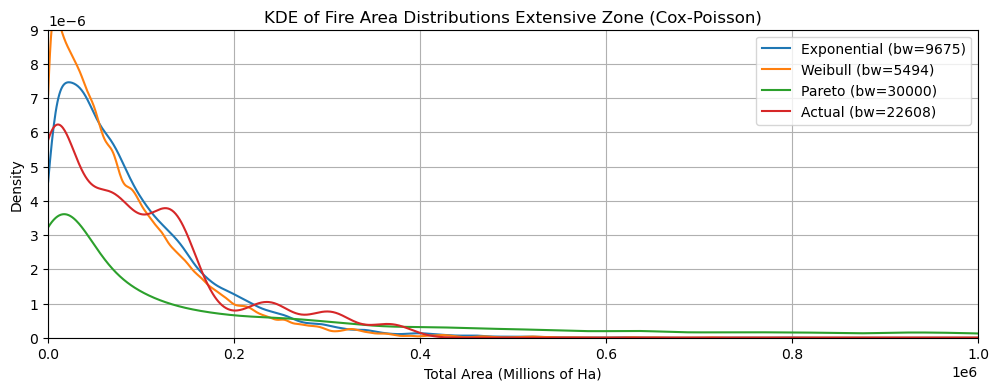

In [6]:
#group extensive by year and sum the total SIZE_HA

extensive_grouped = extensive.groupby('YEAR')['SIZE_HA'].sum().reset_index()

# add to long df but remove the year and the disteibution is called 'actual'
extensive_grouped.rename(columns={'SIZE_HA': 'total_area'}, inplace=True)
extensive_grouped['distribution'] = 'actual'
# drop the YEAR column
extensive_grouped.drop(columns='YEAR', inplace=True)

# concatenate the two DataFrames
combined_df = pd.concat([long_df, extensive_grouped], ignore_index=True)

plt.figure(figsize=(12, 4)) 

bandwidth_dict = {
    "exponential": 9675,
    "weibull": 5494,
    "pareto": 30000,
    "actual": 22608
}

for distribution in combined_df['distribution'].unique():
    # Remove NaN and values > 1,000,000
    subset = combined_df[
        (combined_df['distribution'] == distribution) &
        (combined_df['total_area'].notna())
    ]['total_area']
    X = subset.values[:, None]

    # Use specified bandwidth for each distribution
    bw = bandwidth_dict.get(distribution, 10000)
    kde = KernelDensity(kernel='gaussian', bandwidth=bw)
    kde.fit(X)

    x_d = np.linspace(0, 1000000, 1000)
    log_dens = kde.score_samples(x_d[:, None])
    plt.plot(x_d, np.exp(log_dens), label=f"{distribution.capitalize()} (bw={bw:.0f})")

plt.title('KDE of Fire Area Distributions Extensive Zone (Cox-Poisson)')
plt.xlabel('Total Area (Millions of Ha)')
plt.ylabel('Density')
plt.legend()
plt.xlim(0, 1000000)
plt.ylim(0, 0.000009)
plt.grid()
plt.show()


## Intensive Zone

In [7]:
# get parameters for fire size distribution
fire_size_params = fit_fire_size_distribution(intensive['SIZE_HA'])

# get the number of fires each year
fire_counts = intensive.groupby('YEAR').size()

# get parameters for the Cox process
cox_params = fit_cox_process(fire_counts)

# generate samples
simulated_number_fires = generate_samples(cox_params, size=10000)

# apply generate_fire_area to the simulated number of fires
gamma_cox_simulated_fires_intensive = [generate_fire_area(x, fire_size_params) for x in simulated_number_fires['gamma']]

# Convert list of dicts to DataFrame
gamma_cox_simulated_fires_df_intensive = pd.DataFrame(gamma_cox_simulated_fires_intensive)

# truncate all values to 1000000
gamma_cox_simulated_fires_df_intensive_truncated = gamma_cox_simulated_fires_df_intensive

# Melt the DataFrame to long format
long_df = gamma_cox_simulated_fires_df_intensive_truncated.melt(var_name='distribution', value_name='total_area')

# Melt the DataFrame to long format
#long_df = gamma_cox_simulated_fires_df.melt(var_name='distribution', value_name='total_area')


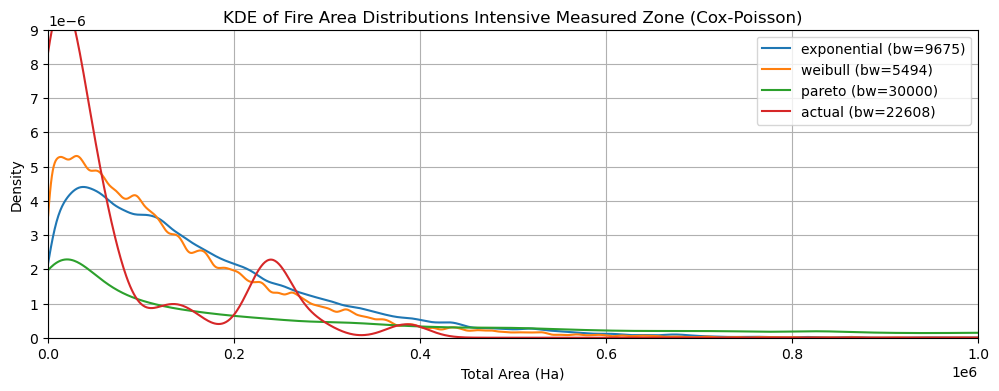

In [17]:
#group extensive by year and sum the total SIZE_HA

extensive_grouped = intensive.groupby('YEAR')['SIZE_HA'].sum().reset_index()

# add to long df but remove the year and the disteibution is called 'actual'
extensive_grouped.rename(columns={'SIZE_HA': 'total_area'}, inplace=True)
extensive_grouped['distribution'] = 'actual'
# drop the YEAR column
extensive_grouped.drop(columns='YEAR', inplace=True)

# concatenate the two DataFrames
combined_df = pd.concat([long_df, extensive_grouped], ignore_index=True)

bandwidth_dict = {
    "exponential": 9675,
    "weibull": 5494,
    "pareto": 30000,
    "actual": 22608
}

plt.figure(figsize=(12, 4))

for distribution in combined_df['distribution'].unique():
    subset = combined_df[combined_df['distribution'] == distribution]['total_area'].dropna()
    X = subset.values[:, None]

    # Use the specified bandwidth for each distribution
    bw = bandwidth_dict.get(distribution, 10000)  # default if not found
    kde = KernelDensity(kernel='gaussian', bandwidth=bw)
    kde.fit(X)

    x_d = np.linspace(0, 1000000, 1000)
    log_dens = kde.score_samples(x_d[:, None])
    plt.plot(x_d, np.exp(log_dens), label=f"{distribution} (bw={bw:.0f})")

plt.title('KDE of Fire Area Distributions Intensive Measured Zone (Cox-Poisson)')
plt.xlabel('Total Area (Ha)')
plt.ylabel('Density')
plt.legend()
plt.xlim(0, 1000000)
plt.ylim(0, 0.000009)
plt.grid()
plt.show()

# All Zones

In [14]:
# get parameters for fire size distribution
fire_size_params = fit_fire_size_distribution(all_fires['SIZE_HA'])

# get the number of fires each year
fire_counts = all_fires.groupby('YEAR').size()

# get parameters for the Cox process
cox_params = fit_cox_process(fire_counts)

# generate samples
simulated_number_fires = generate_samples(cox_params, size=10000)

# apply generate_fire_area to the simulated number of fires
gamma_cox_simulated_fires_all = [generate_fire_area(x, fire_size_params) for x in simulated_number_fires['gamma']]

# Convert list of dicts to DataFrame
gamma_cox_simulated_fires_df_all = pd.DataFrame(gamma_cox_simulated_fires_all)

# truncate all values to 1000000
gamma_cox_simulated_fires_df_all_truncated = gamma_cox_simulated_fires_df_all

# Melt the DataFrame to long format
long_df = gamma_cox_simulated_fires_df_all_truncated.melt(var_name='distribution', value_name='total_area')



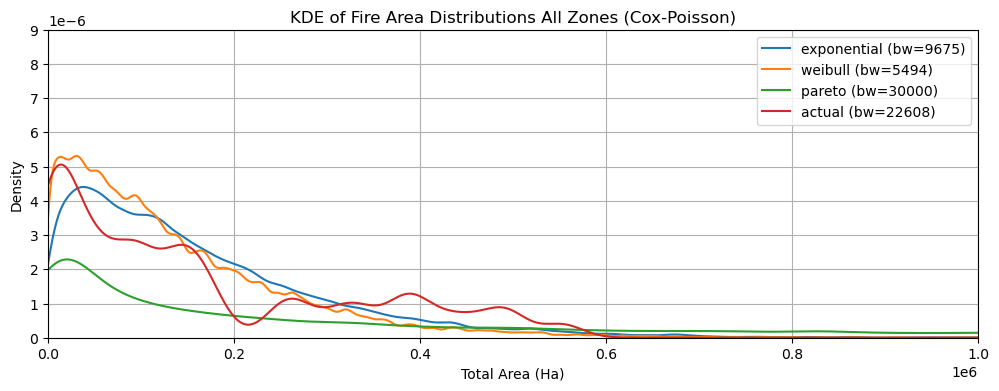

In [18]:
#group extensive by year and sum the total SIZE_HA

extensive_grouped = all_fires.groupby('YEAR')['SIZE_HA'].sum().reset_index()

# add to long df but remove the year and the disteibution is called 'actual'
extensive_grouped.rename(columns={'SIZE_HA': 'total_area'}, inplace=True)
extensive_grouped['distribution'] = 'actual'
# drop the YEAR column
extensive_grouped.drop(columns='YEAR', inplace=True)

# concatenate the two DataFrames
combined_df = pd.concat([long_df, extensive_grouped], ignore_index=True)

bandwidth_dict = {
    "exponential": 9675,
    "weibull": 5494,
    "pareto": 30000,
    "actual": 22608
}

plt.figure(figsize=(12, 4))

for distribution in combined_df['distribution'].unique():
    subset = combined_df[combined_df['distribution'] == distribution]['total_area'].dropna()
    X = subset.values[:, None]

    # Use the specified bandwidth for each distribution
    bw = bandwidth_dict.get(distribution, 10000)  # default if not found
    kde = KernelDensity(kernel='gaussian', bandwidth=bw)
    kde.fit(X)

    x_d = np.linspace(0, 1000000, 1000)
    log_dens = kde.score_samples(x_d[:, None])
    plt.plot(x_d, np.exp(log_dens), label=f"{distribution} (bw={bw:.0f})")

plt.title('KDE of Fire Area Distributions All Zones (Cox-Poisson)')
plt.xlabel('Total Area (Ha)')
plt.ylabel('Density')
plt.legend()
plt.xlim(0, 1000000)
plt.ylim(0, 0.000009)
plt.grid()
plt.show()


# Constant Intensity Poisson Simulaiton

## Extensive

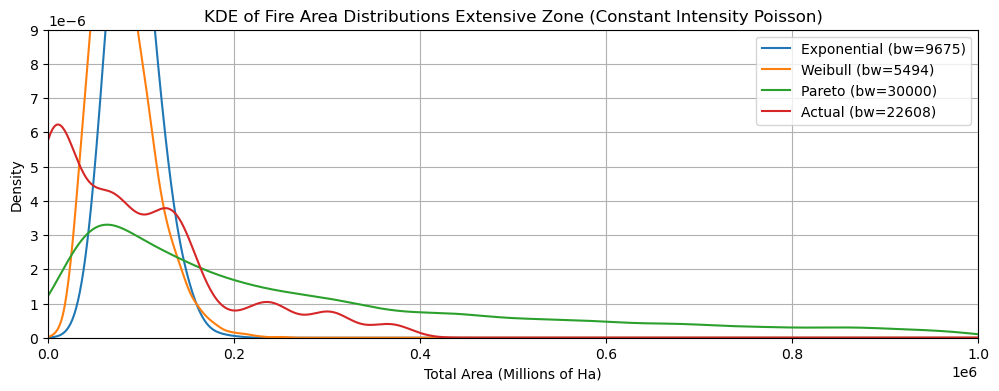

In [22]:
# get parameters for fire size distribution
fire_size_params = fit_fire_size_distribution(extensive['SIZE_HA'])

# get the number of fires each year
fire_counts = extensive.groupby('YEAR').size()

# get parameters for the Cox process (contains constant lambda too)
cox_params = fit_cox_process(fire_counts)

# generate samples using constant lambda (Poisson process)
simulated_number_fires = generate_samples(cox_params, size=10000)
poisson_simulated_fires_all = [generate_fire_area(x, fire_size_params) for x in simulated_number_fires['constant']]

# Convert list of dicts to DataFrame
poisson_simulated_fires_df_all = pd.DataFrame(poisson_simulated_fires_all)

# truncate all values to 1000000
poisson_simulated_fires_df_all_truncated = poisson_simulated_fires_df_all

# Melt the DataFrame to long format
long_df_poisson = poisson_simulated_fires_df_all_truncated.melt(var_name='distribution', value_name='total_area')


extensive_grouped = extensive.groupby('YEAR')['SIZE_HA'].sum().reset_index()

# add to long df but remove the year and the disteibution is called 'actual'
extensive_grouped.rename(columns={'SIZE_HA': 'total_area'}, inplace=True)
extensive_grouped['distribution'] = 'actual'
# drop the YEAR column
extensive_grouped.drop(columns='YEAR', inplace=True)

# concatenate the two DataFrames
combined_poisson_df = pd.concat([long_df_poisson, extensive_grouped], ignore_index=True)

plt.figure(figsize=(12, 4))

bandwidth_dict = {
    "exponential": 9675,
    "weibull": 5494,
    "pareto": 30000,
    "actual": 22608
}

for distribution in combined_poisson_df['distribution'].unique():
    # Remove NaN and values > 1,000,000 if needed
    subset = combined_poisson_df[
        (combined_poisson_df['distribution'] == distribution) &
        (combined_poisson_df['total_area'].notna()) &
        (combined_poisson_df['total_area'] <= 1_000_000)
    ]['total_area']
    X = subset.values[:, None]

    # Use specified bandwidth for each distribution
    bw = bandwidth_dict.get(distribution, 10000)
    kde = KernelDensity(kernel='gaussian', bandwidth=bw)
    kde.fit(X)

    x_d = np.linspace(0, 1000000, 1000)
    log_dens = kde.score_samples(x_d[:, None])
    plt.plot(x_d, np.exp(log_dens), label=f"{distribution.capitalize()} (bw={bw:.0f})")

plt.title('KDE of Fire Area Distributions Extensive Zone (Constant Intensity Poisson)')
plt.xlabel('Total Area (Millions of Ha)')
plt.ylabel('Density')
plt.legend()
plt.xlim(0, 1000000)
plt.ylim(0, 0.000009)
plt.grid()
plt.show()

## Intensive Measured

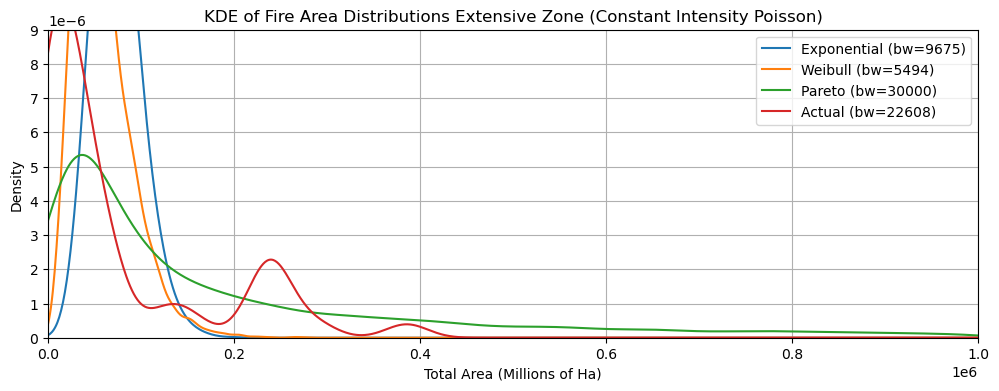

In [21]:
# get parameters for fire size distribution
fire_size_params = fit_fire_size_distribution(intensive['SIZE_HA'])

# get the number of fires each year
fire_counts = intensive.groupby('YEAR').size()

# get parameters for the Cox process (contains constant lambda too)
cox_params = fit_cox_process(fire_counts)

# generate samples using constant lambda (Poisson process)
simulated_number_fires = generate_samples(cox_params, size=10000)
poisson_simulated_fires_all = [generate_fire_area(x, fire_size_params) for x in simulated_number_fires['constant']]

# Convert list of dicts to DataFrame
poisson_simulated_fires_df_all = pd.DataFrame(poisson_simulated_fires_all)

# truncate all values to 1000000
poisson_simulated_fires_df_all_truncated = poisson_simulated_fires_df_all

# Melt the DataFrame to long format
long_df_poisson = poisson_simulated_fires_df_all_truncated.melt(var_name='distribution', value_name='total_area')


extensive_grouped = intensive.groupby('YEAR')['SIZE_HA'].sum().reset_index()

# add to long df but remove the year and the disteibution is called 'actual'
extensive_grouped.rename(columns={'SIZE_HA': 'total_area'}, inplace=True)
extensive_grouped['distribution'] = 'actual'
# drop the YEAR column
extensive_grouped.drop(columns='YEAR', inplace=True)

# concatenate the two DataFrames
combined_poisson_df = pd.concat([long_df_poisson, extensive_grouped], ignore_index=True)

plt.figure(figsize=(12, 4))

bandwidth_dict = {
    "exponential": 9675,
    "weibull": 5494,
    "pareto": 30000,
    "actual": 22608
}

for distribution in combined_poisson_df['distribution'].unique():
    # Remove NaN and values > 1,000,000 if needed
    subset = combined_poisson_df[
        (combined_poisson_df['distribution'] == distribution) &
        (combined_poisson_df['total_area'].notna()) &
        (combined_poisson_df['total_area'] <= 1_000_000)
    ]['total_area']
    X = subset.values[:, None]

    # Use specified bandwidth for each distribution
    bw = bandwidth_dict.get(distribution, 10000)
    kde = KernelDensity(kernel='gaussian', bandwidth=bw)
    kde.fit(X)

    x_d = np.linspace(0, 1000000, 1000)
    log_dens = kde.score_samples(x_d[:, None])
    plt.plot(x_d, np.exp(log_dens), label=f"{distribution.capitalize()} (bw={bw:.0f})")

plt.title('KDE of Fire Area Distributions Extensive Zone (Constant Intensity Poisson)')
plt.xlabel('Total Area (Millions of Ha)')
plt.ylabel('Density')
plt.legend()
plt.xlim(0, 1000000)
plt.ylim(0, 0.000009)
plt.grid()
plt.show()

## All Zones

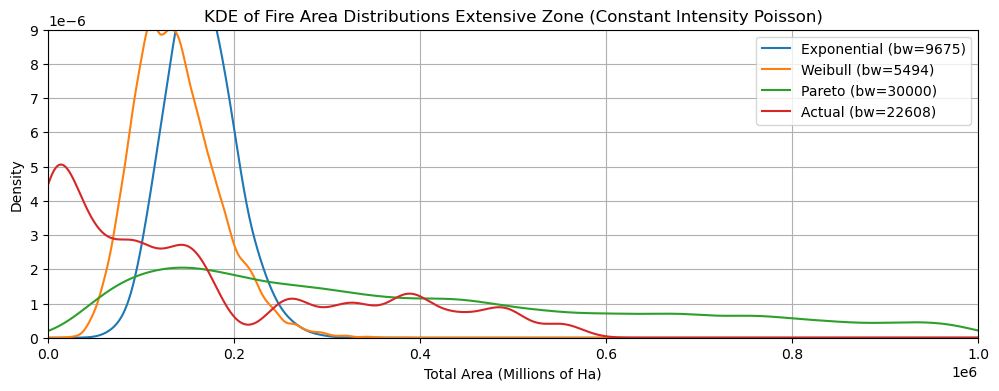

In [23]:
# get parameters for fire size distribution
fire_size_params = fit_fire_size_distribution(all_fires['SIZE_HA'])

# get the number of fires each year
fire_counts = all_fires.groupby('YEAR').size()

# get parameters for the Cox process (contains constant lambda too)
cox_params = fit_cox_process(fire_counts)

# generate samples using constant lambda (Poisson process)
simulated_number_fires = generate_samples(cox_params, size=10000)
poisson_simulated_fires_all = [generate_fire_area(x, fire_size_params) for x in simulated_number_fires['constant']]

# Convert list of dicts to DataFrame
poisson_simulated_fires_df_all = pd.DataFrame(poisson_simulated_fires_all)

# truncate all values to 1000000
poisson_simulated_fires_df_all_truncated = poisson_simulated_fires_df_all

# Melt the DataFrame to long format
long_df_poisson = poisson_simulated_fires_df_all_truncated.melt(var_name='distribution', value_name='total_area')


extensive_grouped = all_fires.groupby('YEAR')['SIZE_HA'].sum().reset_index()

# add to long df but remove the year and the disteibution is called 'actual'
extensive_grouped.rename(columns={'SIZE_HA': 'total_area'}, inplace=True)
extensive_grouped['distribution'] = 'actual'
# drop the YEAR column
extensive_grouped.drop(columns='YEAR', inplace=True)

# concatenate the two DataFrames
combined_poisson_df = pd.concat([long_df_poisson, extensive_grouped], ignore_index=True)

plt.figure(figsize=(12, 4))

bandwidth_dict = {
    "exponential": 9675,
    "weibull": 5494,
    "pareto": 30000,
    "actual": 22608
}

for distribution in combined_poisson_df['distribution'].unique():
    # Remove NaN and values > 1,000,000 if needed
    subset = combined_poisson_df[
        (combined_poisson_df['distribution'] == distribution) &
        (combined_poisson_df['total_area'].notna()) &
        (combined_poisson_df['total_area'] <= 1_000_000)
    ]['total_area']
    X = subset.values[:, None]

    # Use specified bandwidth for each distribution
    bw = bandwidth_dict.get(distribution, 10000)
    kde = KernelDensity(kernel='gaussian', bandwidth=bw)
    kde.fit(X)

    x_d = np.linspace(0, 1000000, 1000)
    log_dens = kde.score_samples(x_d[:, None])
    plt.plot(x_d, np.exp(log_dens), label=f"{distribution.capitalize()} (bw={bw:.0f})")

plt.title('KDE of Fire Area Distributions Extensive Zone (Constant Intensity Poisson)')
plt.xlabel('Total Area (Millions of Ha)')
plt.ylabel('Density')
plt.legend()
plt.xlim(0, 1000000)
plt.ylim(0, 0.000009)
plt.grid()
plt.show()

# Temporal Trend

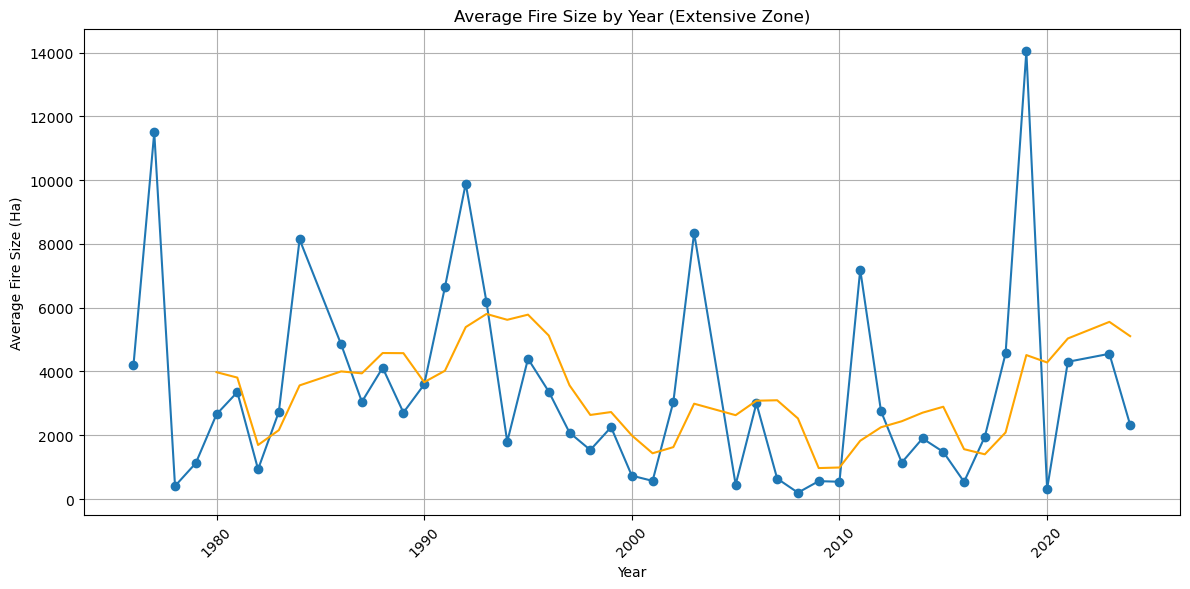

In [ ]:
# average fire size by year
average_fire_size_extensive = extensive.groupby('YEAR')['SIZE_HA'].mean().reset_index()

# plot average fire size by year 
plt.figure(figsize=(12, 6))
plt.plot(average_fire_size_extensive['YEAR'], average_fire_size_extensive['SIZE_HA'], marker='o', linestyle='-')
# plot a moving average
average_fire_size_extensive['SIZE_HA_MA'] = average_fire_size_extensive['SIZE_HA'].rolling(window=5).mean()
plt.plot(average_fire_size_extensive['YEAR'], average_fire_size_extensive['SIZE_HA_MA'], color='orange', label='5-Year Moving Average')
plt.title('Average Fire Size by Year (Extensive Zone)')
plt.xlabel('Year')
plt.ylabel('Average Fire Size (Ha)')
plt.grid()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


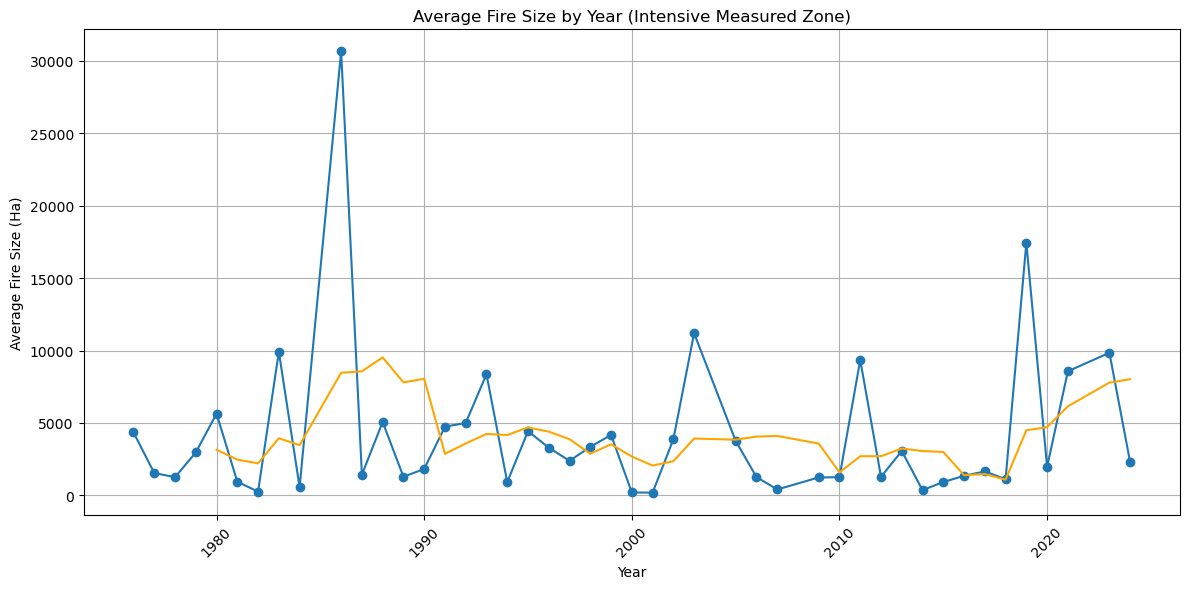

In [ ]:
# Do the same for intensive zone
average_fire_size_intensive = intensive.groupby('YEAR')['SIZE_HA'].mean().reset_index()
# plot average fire size by year
plt.figure(figsize=(12, 6))
plt.plot(average_fire_size_intensive['YEAR'], average_fire_size_intensive['SIZE_HA'], marker='o', linestyle='-')
# plot a moving average
average_fire_size_intensive['SIZE_HA_MA'] = average_fire_size_intensive['SIZE_HA'].rolling(window=5).mean()
plt.plot(average_fire_size_intensive['YEAR'], average_fire_size_intensive['SIZE_HA_MA'], color='orange', label='5-Year Moving Average')
plt.title('Average Fire Size by Year (Intensive Measured Zone)')
plt.xlabel('Year')
plt.ylabel('Average Fire Size (Ha)')
plt.grid()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\LiW\AppData\Local\Temp\ipykernel_10224\568630211.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_per_year, labels=years_full)


C:\Users\LiW\AppData\Local\Temp\ipykernel_10224\568630211.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_per_year, labels=years_full)


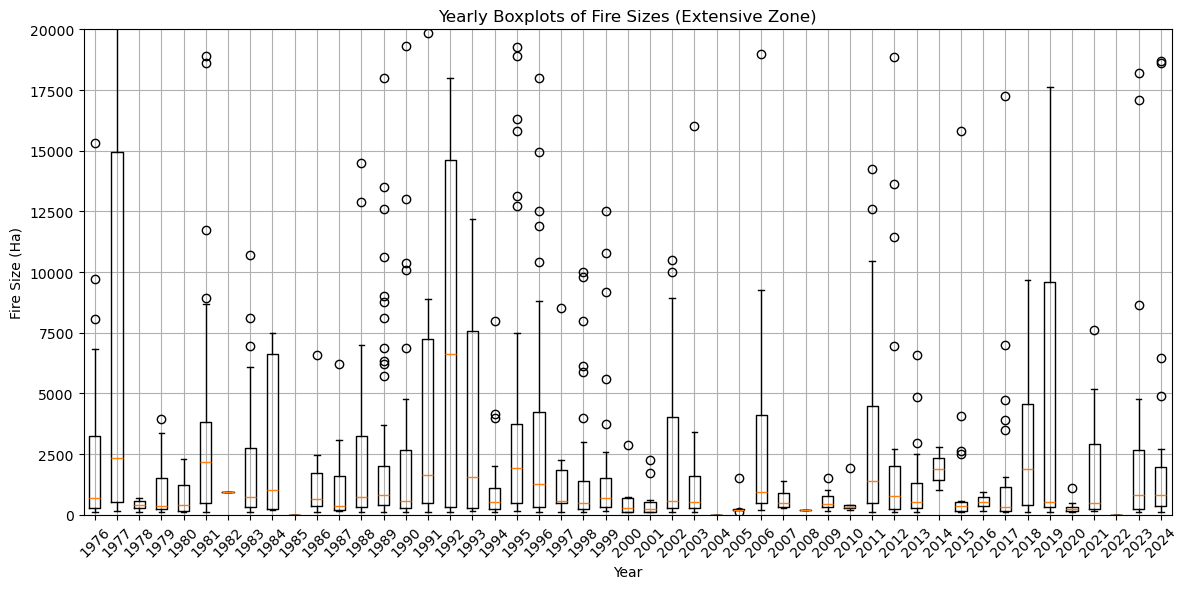

In [36]:
# make yearly boxplots of the fire sizes for extensive zone
plt.figure(figsize=(12, 6))
# Get the full range of years (including years with no fires)
years_full = np.arange(extensive['YEAR'].min(), extensive['YEAR'].max() + 1)
data_per_year = [
extensive[extensive['YEAR'] == year]['SIZE_HA'].values if year in extensive['YEAR'].values else [0]
    for year in years_full
]
plt.boxplot(data_per_year, labels=years_full)
plt.title('Yearly Boxplots of Fire Sizes (Extensive Zone)')
plt.xlabel('Year')
plt.ylabel('Fire Size (Ha)')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()


C:\Users\LiW\AppData\Local\Temp\ipykernel_23896\3809511070.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(data_per_year, labels=years_full, showfliers=False)


C:\Users\LiW\AppData\Local\Temp\ipykernel_23896\3809511070.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(data_per_year, labels=years_full, showfliers=False)


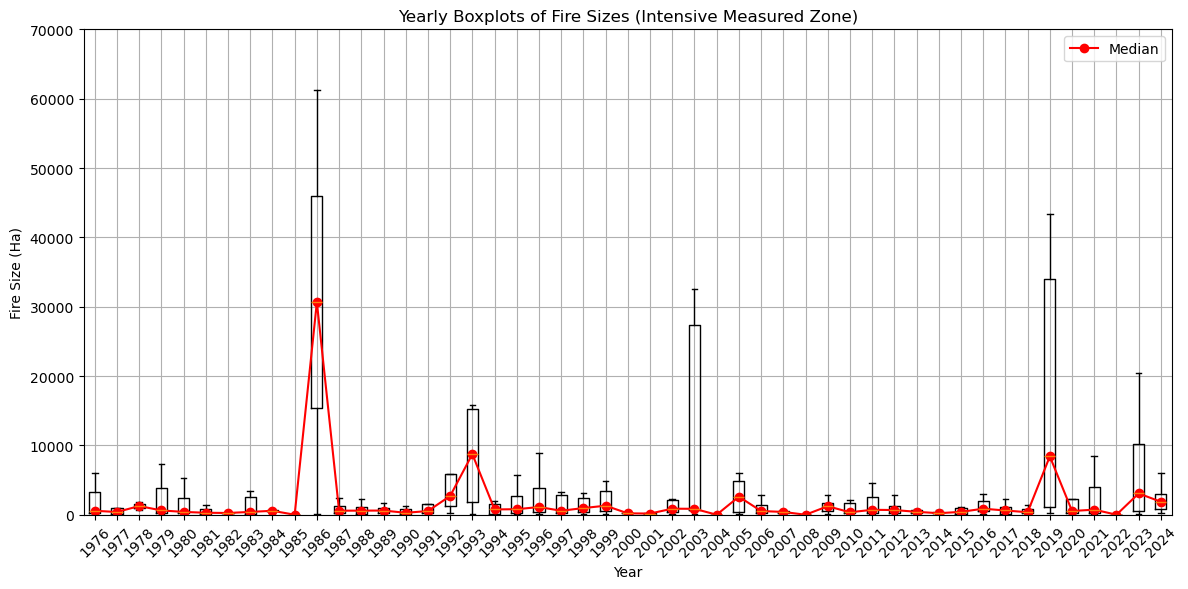

In [14]:
# make yearly boxplots of the fire sizes for extensive zone
plt.figure(figsize=(12, 6))
# Get the full range of years (including years with no fires)
years_full = np.arange(intensive['YEAR'].min(), intensive['YEAR'].max() + 1)
data_per_year = [
    intensive[intensive['YEAR'] == year]['SIZE_HA'].values if year in intensive['YEAR'].values else [0]
    for year in years_full
]
plt.boxplot(data_per_year, labels=years_full)
plt.title('Yearly Boxplots of Fire Sizes (Intensive Measured Zone)')
plt.xlabel('Year')
plt.ylabel('Fire Size (Ha)')
plt.xticks(rotation=45)
plt.ylim(0, 70000)
plt.grid()
plt.tight_layout()
plt.show()


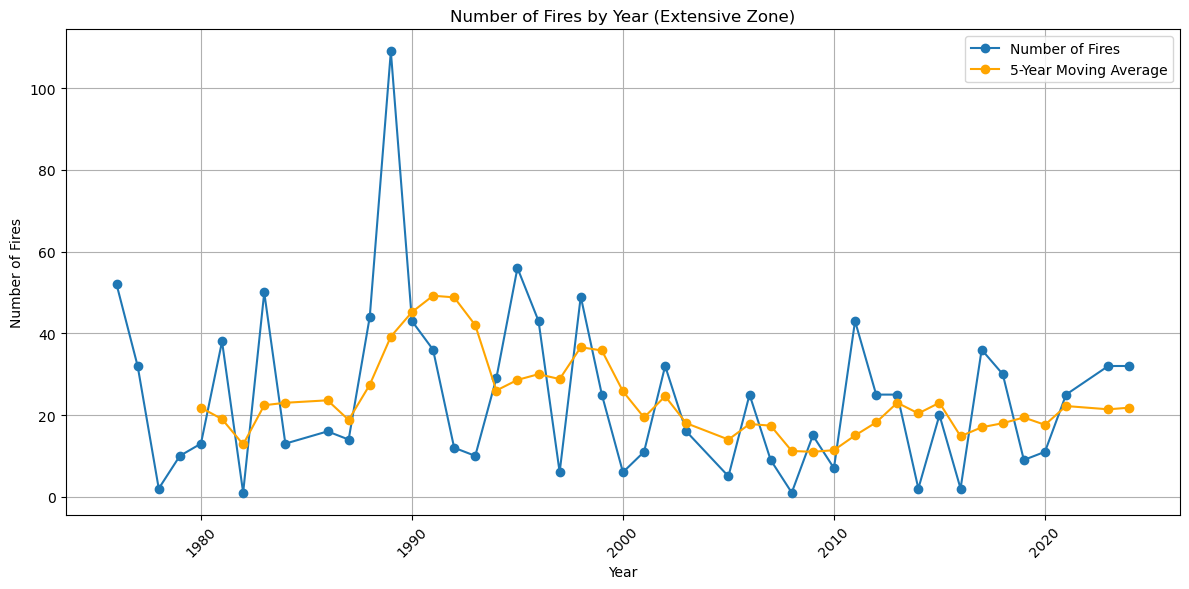

In [ ]:
# number of fires by year and then do a moving average too
# number of fires by year
fire_counts_extensive = extensive.groupby('YEAR')['SIZE_HA'].count().reset_index()
# calculate moving average
fire_counts_extensive['moving_average'] = fire_counts_extensive['SIZE_HA'].rolling(window=5).mean()
# plot number of fires by year and moving average
plt.figure(figsize=(12, 6))
plt.plot(fire_counts_extensive['YEAR'], fire_counts_extensive['SIZE_HA'], marker='o', linestyle='-', label='Number of Fires')
plt.plot(fire_counts_extensive['YEAR'], fire_counts_extensive['moving_average'], marker='o', linestyle='-', color='orange', label='5-Year Moving Average')
plt.title('Number of Fires by Year (Extensive Zone)')
plt.xlabel('Year')
plt.ylabel('Number of Fires')
plt.legend()
plt.grid()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

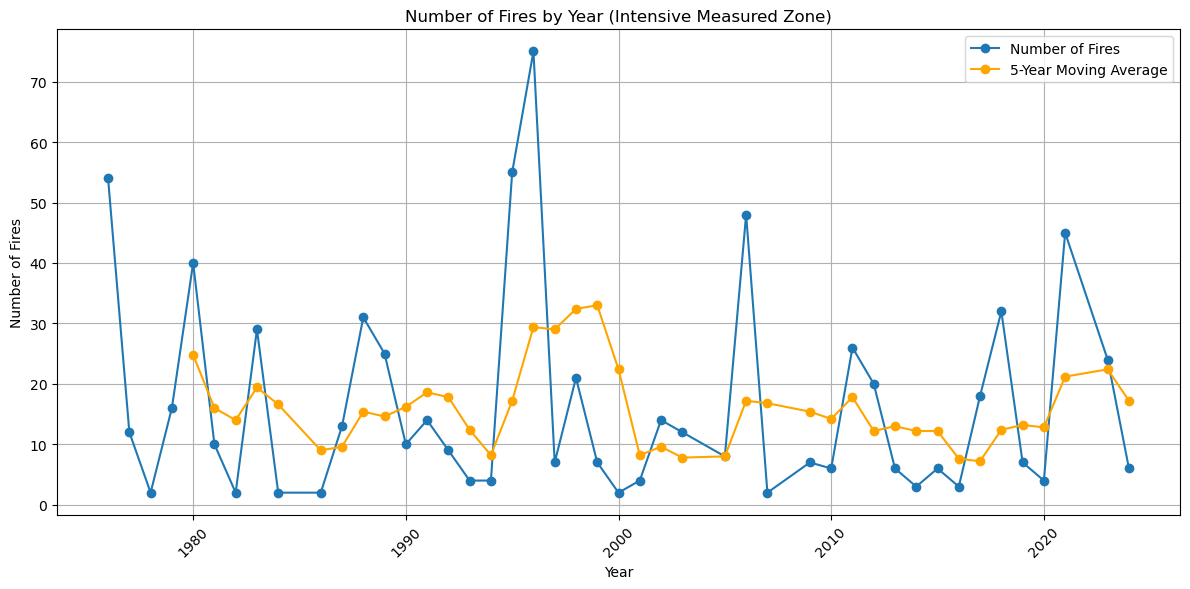

In [ ]:
# dop the same for the intensive zone
# number of fires by year
fire_counts_intensive = intensive.groupby('YEAR')['SIZE_HA'].count().reset_index()
# calculate moving average
fire_counts_intensive['moving_average'] = fire_counts_intensive['SIZE_HA'].rolling(window=5).mean()
# plot number of fires by year and moving average
plt.figure(figsize=(12, 6))
plt.plot(fire_counts_intensive['YEAR'], fire_counts_intensive['SIZE_HA'], marker='o', linestyle='-', label='Number of Fires')
plt.plot(fire_counts_intensive['YEAR'], fire_counts_intensive['moving_average'], marker='o', linestyle='-', color='orange', label='5-Year Moving Average')
plt.title('Number of Fires by Year (Intensive Measured Zone)')
plt.xlabel('Year')
plt.ylabel('Number of Fires')
plt.legend()
plt.grid()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


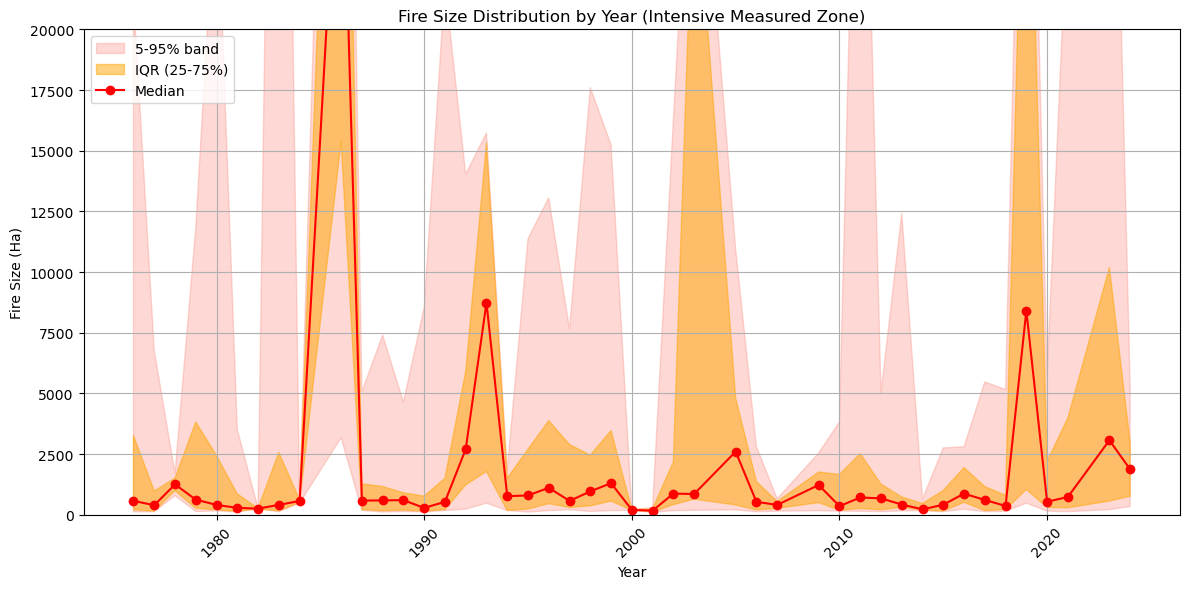

In [16]:
# Plot median, IQR, and 5-95% bands of fire sizes by year for Intensive Measured Zone
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Group by year and aggregate statistics
stats = intensive.groupby('YEAR')['SIZE_HA'].agg([
    ('median', 'median'),
    ('q25', lambda x: np.percentile(x, 25)),
    ('q75', lambda x: np.percentile(x, 75)),
    ('p5', lambda x: np.percentile(x, 5)),
    ('p95', lambda x: np.percentile(x, 95))
]).reset_index()

plt.figure(figsize=(12, 6))
# 5-95% band
plt.fill_between(stats['YEAR'], stats['p5'], stats['p95'], color='salmon', alpha=0.3, label='5-95% band')
# IQR band
plt.fill_between(stats['YEAR'], stats['q25'], stats['q75'], color='orange', alpha=0.5, label='IQR (25-75%)')
# Median line
plt.plot(stats['YEAR'], stats['median'], color='red', marker='o', label='Median')
plt.title('Fire Size Distribution by Year (Intensive Measured Zone)')
plt.xlabel('Year')
plt.ylabel('Fire Size (Ha)')
plt.xticks(rotation=45)
plt.ylim(0, 20000)
plt.grid()
plt.tight_layout()
plt.legend()
plt.show()

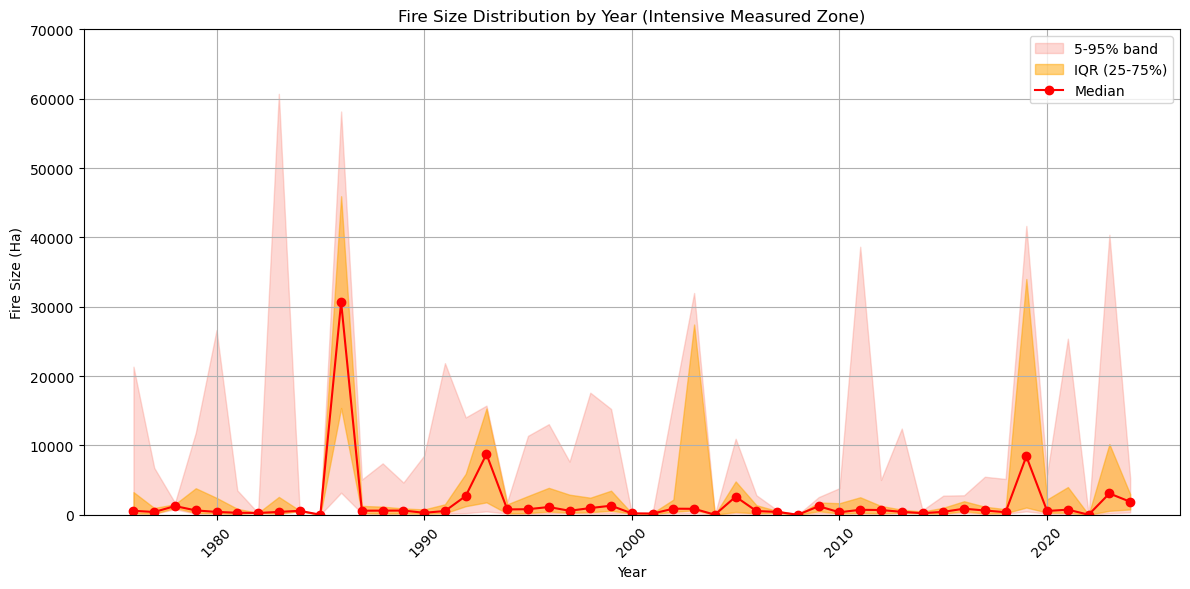

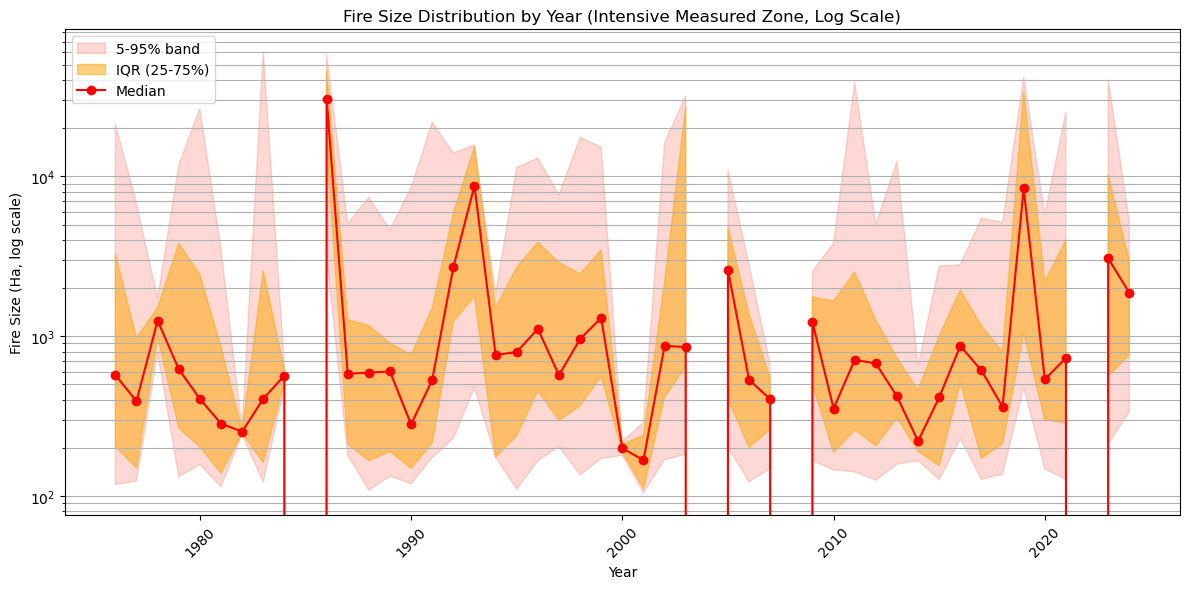

In [19]:
# Plot median, IQR, and 5-95% bands of fire sizes by year for Intensive Measured Zone
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Group by year and aggregate statistics
stats = intensive.groupby('YEAR')['SIZE_HA'].agg([
    ('median', 'median'),
    ('q25', lambda x: np.percentile(x, 25)),
    ('q75', lambda x: np.percentile(x, 75)),
    ('p5', lambda x: np.percentile(x, 5)),
    ('p95', lambda x: np.percentile(x, 95))
]).reset_index()

# Add zeroes for years with no fires
all_years = np.arange(intensive['YEAR'].min(), intensive['YEAR'].max() + 1)
stats = stats.set_index('YEAR').reindex(all_years).fillna(0).reset_index().rename(columns={'index': 'YEAR'})

plt.figure(figsize=(12, 6))
# 5-95% band
plt.fill_between(stats['YEAR'], stats['p5'], stats['p95'], color='salmon', alpha=0.3, label='5-95% band')
# IQR band
plt.fill_between(stats['YEAR'], stats['q25'], stats['q75'], color='orange', alpha=0.5, label='IQR (25-75%)')
# Median line
plt.plot(stats['YEAR'], stats['median'], color='red', marker='o', label='Median')
plt.title('Fire Size Distribution by Year (Intensive Measured Zone)')
plt.xlabel('Year')
plt.ylabel('Fire Size (Ha)')
plt.xticks(rotation=45)
plt.ylim(0, 70000)
plt.grid()
plt.tight_layout()
plt.legend()
plt.show()

# Plot median, IQR, and 5-95% bands of fire sizes by year for Intensive Measured Zone (log scale)
# Group by year and aggregate statistics
stats = intensive.groupby('YEAR')['SIZE_HA'].agg([
    ('median', 'median'),
    ('q25', lambda x: np.percentile(x, 25)),
    ('q75', lambda x: np.percentile(x, 75)),
    ('p5', lambda x: np.percentile(x, 5)),
    ('p95', lambda x: np.percentile(x, 95))
]).reset_index()

# Add zeroes for years with no fires
stats = stats.set_index('YEAR').reindex(all_years).fillna(0).reset_index().rename(columns={'index': 'YEAR'})

plt.figure(figsize=(12, 6))
# 5-95% band
plt.fill_between(stats['YEAR'], stats['p5'], stats['p95'], color='salmon', alpha=0.3, label='5-95% band')
# IQR band
plt.fill_between(stats['YEAR'], stats['q25'], stats['q75'], color='orange', alpha=0.5, label='IQR (25-75%)')
# Median line
plt.plot(stats['YEAR'], stats['median'], color='red', marker='o', label='Median')
plt.title('Fire Size Distribution by Year (Intensive Measured Zone, Log Scale)')
plt.xlabel('Year')
plt.ylabel('Fire Size (Ha, log scale)')
plt.yscale('log')
plt.xticks(rotation=45)
plt.grid(True, which='both', axis='y')
plt.tight_layout()
plt.legend()
plt.show()

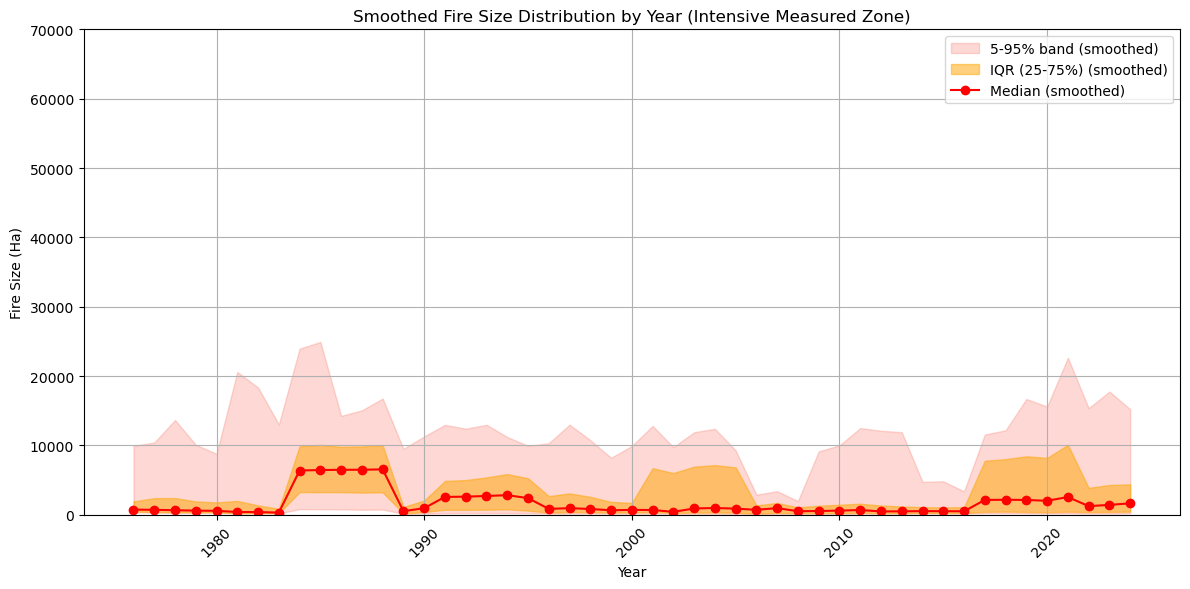

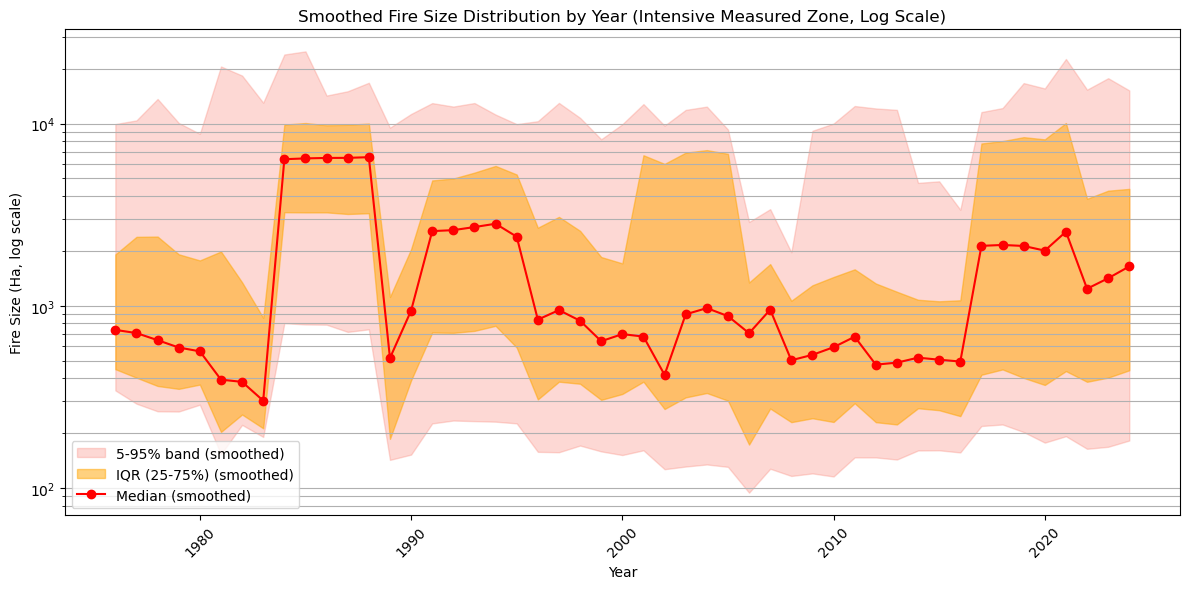

In [20]:
# Smoothed (rolling) 5-95% band, IQR, and median for Intensive Measured Zone
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Group by year and aggregate statistics
stats = intensive.groupby('YEAR')['SIZE_HA'].agg([
    ('median', 'median'),
    ('q25', lambda x: np.percentile(x, 25)),
    ('q75', lambda x: np.percentile(x, 75)),
    ('p5', lambda x: np.percentile(x, 5)),
    ('p95', lambda x: np.percentile(x, 95))
]).reset_index()

# Add zeroes for years with no fires
all_years = np.arange(intensive['YEAR'].min(), intensive['YEAR'].max() + 1)
stats = stats.set_index('YEAR').reindex(all_years).fillna(0).reset_index().rename(columns={'index': 'YEAR'})

# Apply rolling window smoothing (5 years)
window = 5
stats_rolled = stats[['median', 'q25', 'q75', 'p5', 'p95']].rolling(window=window, min_periods=1, center=True).mean()

plt.figure(figsize=(12, 6))
# 5-95% band (smoothed)
plt.fill_between(stats['YEAR'], stats_rolled['p5'], stats_rolled['p95'], color='salmon', alpha=0.3, label='5-95% band (smoothed)')
# IQR band (smoothed)
plt.fill_between(stats['YEAR'], stats_rolled['q25'], stats_rolled['q75'], color='orange', alpha=0.5, label='IQR (25-75%) (smoothed)')
# Median line (smoothed)
plt.plot(stats['YEAR'], stats_rolled['median'], color='red', marker='o', label='Median (smoothed)')
plt.title('Smoothed Fire Size Distribution by Year (Intensive Measured Zone)')
plt.xlabel('Year')
plt.ylabel('Fire Size (Ha)')
plt.xticks(rotation=45)
plt.ylim(0, 70000)
plt.grid()
plt.tight_layout()
plt.legend()
plt.show()

# Log scale version
plt.figure(figsize=(12, 6))
plt.fill_between(stats['YEAR'], stats_rolled['p5'], stats_rolled['p95'], color='salmon', alpha=0.3, label='5-95% band (smoothed)')
plt.fill_between(stats['YEAR'], stats_rolled['q25'], stats_rolled['q75'], color='orange', alpha=0.5, label='IQR (25-75%) (smoothed)')
plt.plot(stats['YEAR'], stats_rolled['median'], color='red', marker='o', label='Median (smoothed)')
plt.title('Smoothed Fire Size Distribution by Year (Intensive Measured Zone, Log Scale)')
plt.xlabel('Year')
plt.ylabel('Fire Size (Ha, log scale)')
plt.yscale('log')
plt.xticks(rotation=45)
plt.grid(True, which='both', axis='y')
plt.tight_layout()
plt.legend()
plt.show()

In [ ]:
# Smoothed (rolling) 5-95% band, IQR, and median for Intensive Measured Zone
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Group by year and aggregate statistics
stats = ex.groupby('YEAR')['SIZE_HA'].agg([
    ('median', 'median'),
    ('q25', lambda x: np.percentile(x, 25)),
    ('q75', lambda x: np.percentile(x, 75)),
    ('p5', lambda x: np.percentile(x, 5)),
    ('p95', lambda x: np.percentile(x, 95))
]).reset_index()

# Add zeroes for years with no fires
all_years = np.arange(intensive['YEAR'].min(), intensive['YEAR'].max() + 1)
stats = stats.set_index('YEAR').reindex(all_years).fillna(0).reset_index().rename(columns={'index': 'YEAR'})

# Apply rolling window smoothing (5 years)
window = 5
stats_rolled = stats[['median', 'q25', 'q75', 'p5', 'p95']].rolling(window=window, min_periods=1, center=True).mean()

plt.figure(figsize=(12, 6))
# 5-95% band (smoothed)
plt.fill_between(stats['YEAR'], stats_rolled['p5'], stats_rolled['p95'], color='salmon', alpha=0.3, label='5-95% band (smoothed)')
# IQR band (smoothed)
plt.fill_between(stats['YEAR'], stats_rolled['q25'], stats_rolled['q75'], color='orange', alpha=0.5, label='IQR (25-75%) (smoothed)')
# Median line (smoothed)
plt.plot(stats['YEAR'], stats_rolled['median'], color='red', marker='o', label='Median (smoothed)')
plt.title('Smoothed Fire Size Distribution by Year (Intensive Measured Zone)')
plt.xlabel('Year')
plt.ylabel('Fire Size (Ha)')
plt.xticks(rotation=45)
plt.ylim(0, 70000)
plt.grid()
plt.tight_layout()
plt.legend()
plt.show()

# Log scale version
plt.figure(figsize=(12, 6))
plt.fill_between(stats['YEAR'], stats_rolled['p5'], stats_rolled['p95'], color='salmon', alpha=0.3, label='5-95% band (smoothed)')
plt.fill_between(stats['YEAR'], stats_rolled['q25'], stats_rolled['q75'], color='orange', alpha=0.5, label='IQR (25-75%) (smoothed)')
plt.plot(stats['YEAR'], stats_rolled['median'], color='red', marker='o', label='Median (smoothed)')
plt.title('Smoothed Fire Size Distribution by Year (Intensive Measured Zone, Log Scale)')
plt.xlabel('Year')
plt.ylabel('Fire Size (Ha, log scale)')
plt.yscale('log')
plt.xticks(rotation=45)
plt.grid(True, which='both', axis='y')
plt.tight_layout()
plt.legend()
plt.show()

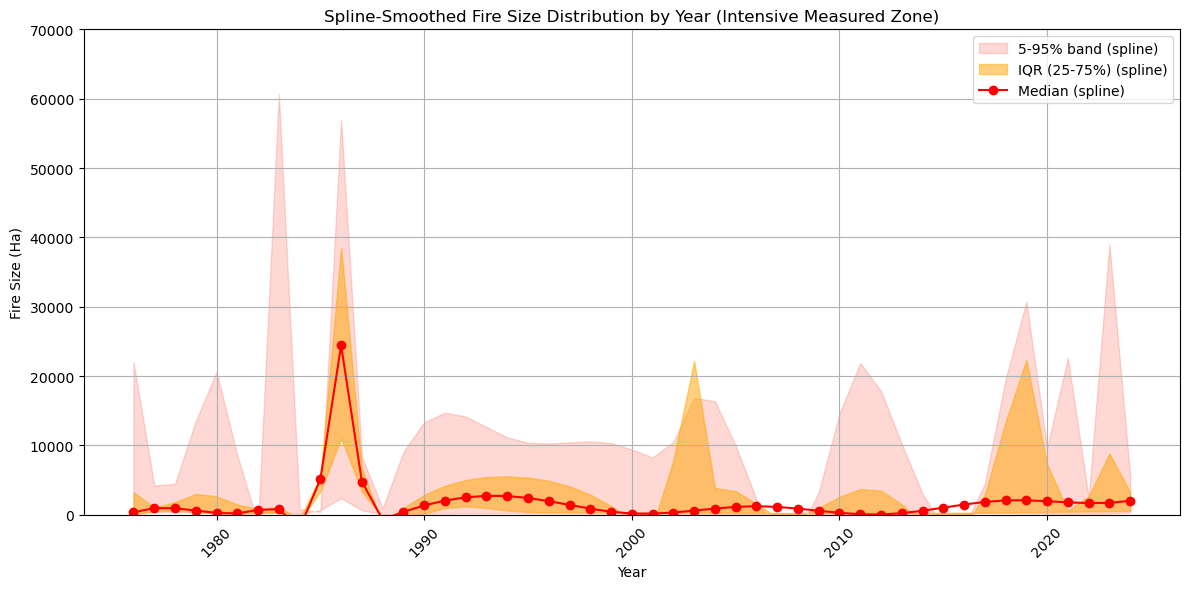

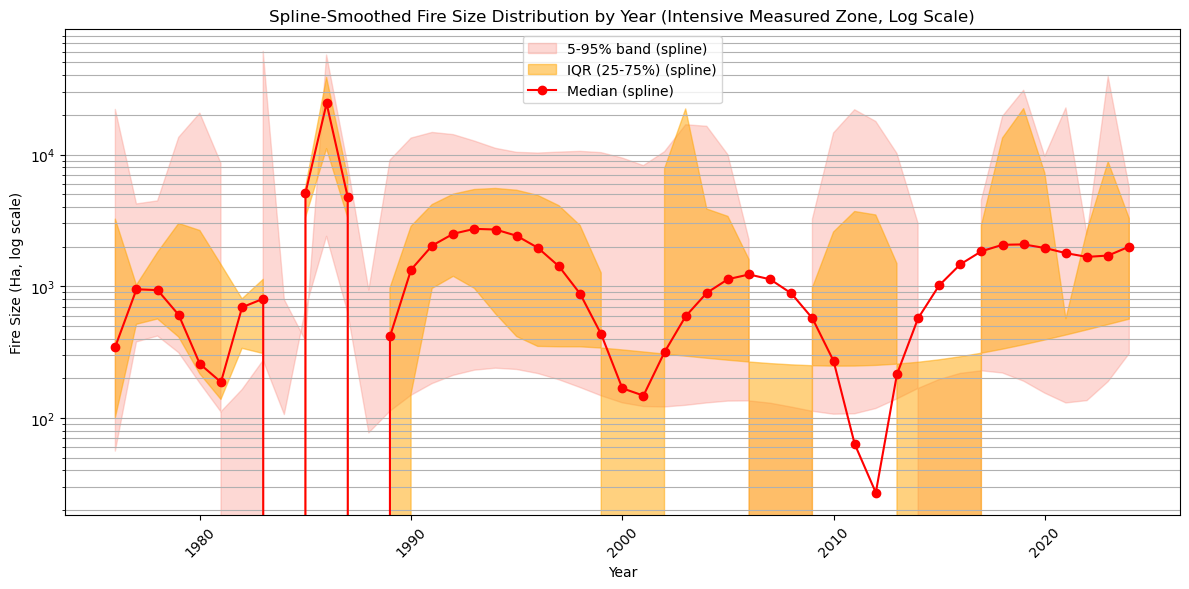

In [21]:
# Spline-smoothed 5-95% band, IQR, and median for Intensive Measured Zone
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline

# Group by year and aggregate statistics
stats = intensive.groupby('YEAR')['SIZE_HA'].agg([
    ('median', 'median'),
    ('q25', lambda x: np.percentile(x, 25)),
    ('q75', lambda x: np.percentile(x, 75)),
    ('p5', lambda x: np.percentile(x, 5)),
    ('p95', lambda x: np.percentile(x, 95))
]).reset_index()

# Add zeroes for years with no fires
all_years = np.arange(intensive['YEAR'].min(), intensive['YEAR'].max() + 1)
stats = stats.set_index('YEAR').reindex(all_years).fillna(0).reset_index().rename(columns={'index': 'YEAR'})

x = stats['YEAR'].values
spline_smooth = {}
for col in ['median', 'q25', 'q75', 'p5', 'p95']:
    y = stats[col].values
    # Use a smoothing factor s; adjust as needed for smoothness
    spline = UnivariateSpline(x, y, s=len(x)*np.var(y)*0.2)
    spline_smooth[col] = spline(x)

plt.figure(figsize=(12, 6))
plt.fill_between(x, spline_smooth['p5'], spline_smooth['p95'], color='salmon', alpha=0.3, label='5-95% band (spline)')
plt.fill_between(x, spline_smooth['q25'], spline_smooth['q75'], color='orange', alpha=0.5, label='IQR (25-75%) (spline)')
plt.plot(x, spline_smooth['median'], color='red', marker='o', label='Median (spline)')
plt.title('Spline-Smoothed Fire Size Distribution by Year (Intensive Measured Zone)')
plt.xlabel('Year')
plt.ylabel('Fire Size (Ha)')
plt.xticks(rotation=45)
plt.ylim(0, 70000)
plt.grid()
plt.tight_layout()
plt.legend()
plt.show()

# Log scale version
plt.figure(figsize=(12, 6))
plt.fill_between(x, spline_smooth['p5'], spline_smooth['p95'], color='salmon', alpha=0.3, label='5-95% band (spline)')
plt.fill_between(x, spline_smooth['q25'], spline_smooth['q75'], color='orange', alpha=0.5, label='IQR (25-75%) (spline)')
plt.plot(x, spline_smooth['median'], color='red', marker='o', label='Median (spline)')
plt.title('Spline-Smoothed Fire Size Distribution by Year (Intensive Measured Zone, Log Scale)')
plt.xlabel('Year')
plt.ylabel('Fire Size (Ha, log scale)')
plt.yscale('log')
plt.xticks(rotation=45)
plt.grid(True, which='both', axis='y')
plt.tight_layout()
plt.legend()
plt.show()

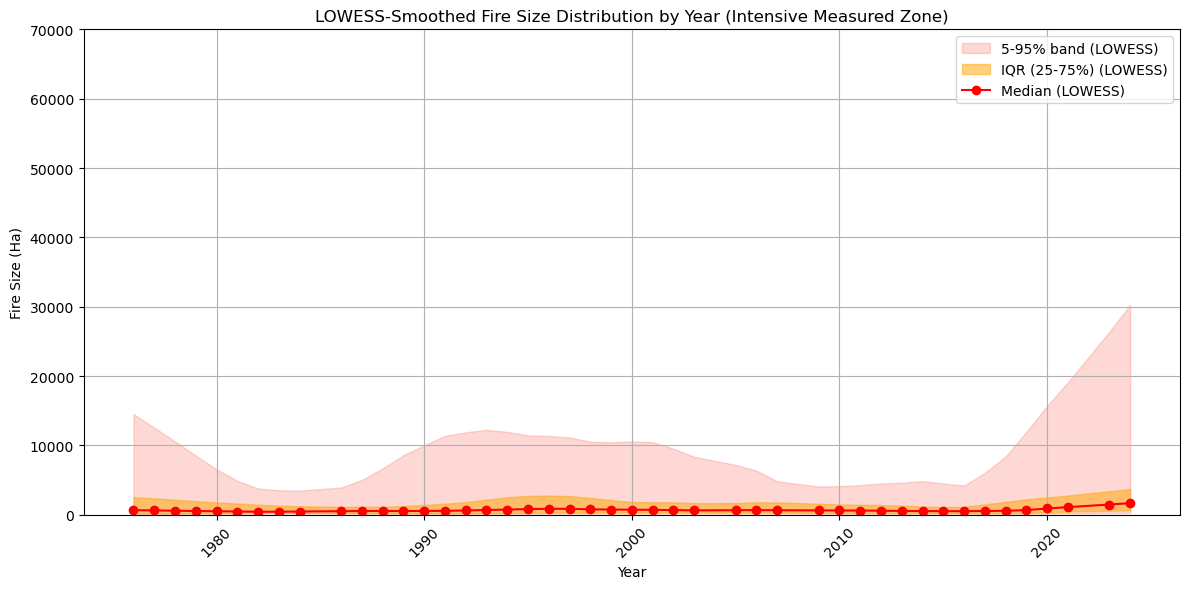

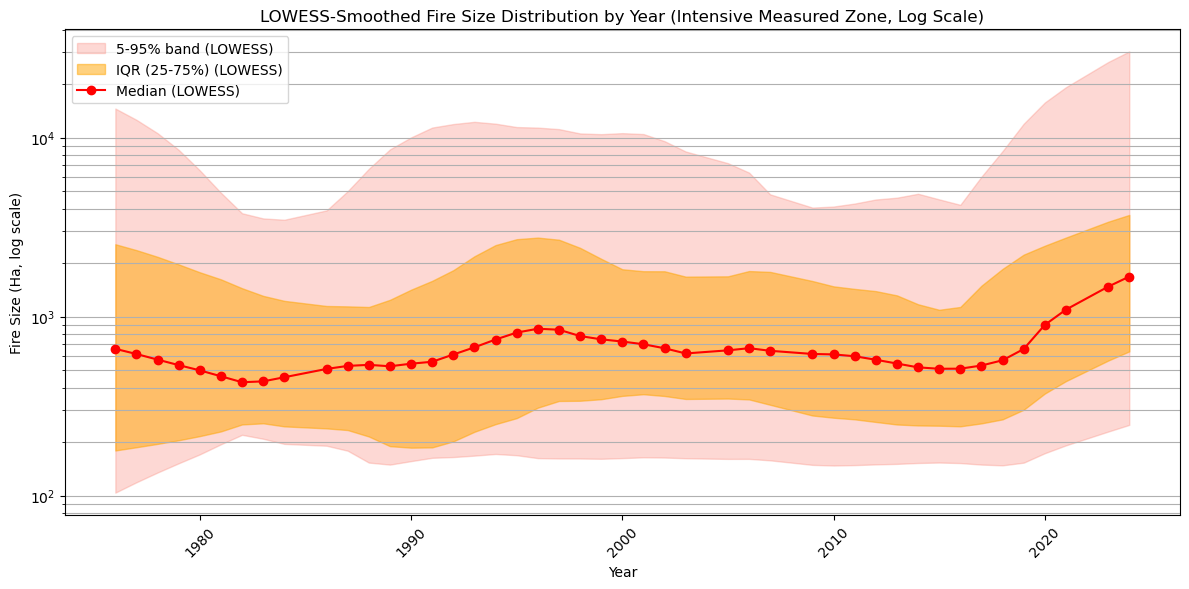

In [23]:
# LOWESS-smoothed 5-95% band, IQR, and median for Intensive Measured Zone (only years with data)
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess

# Group by year and aggregate statistics (only years with data)
stats = intensive.groupby('YEAR')['SIZE_HA'].agg([
    ('median', 'median'),
    ('q25', lambda x: np.percentile(x, 25)),
    ('q75', lambda x: np.percentile(x, 75)),
    ('p5', lambda x: np.percentile(x, 5)),
    ('p95', lambda x: np.percentile(x, 95))
]).reset_index()

x = stats['YEAR'].values
lowess_smooth = {}
frac = 0.25  # Smoothing parameter (adjust as needed)
for col in ['median', 'q25', 'q75', 'p5', 'p95']:
    y = stats[col].values
    smoothed = lowess(y, x, frac=frac, return_sorted=False)
    lowess_smooth[col] = smoothed

plt.figure(figsize=(12, 6))
plt.fill_between(x, lowess_smooth['p5'], lowess_smooth['p95'], color='salmon', alpha=0.3, label='5-95% band (LOWESS)')
plt.fill_between(x, lowess_smooth['q25'], lowess_smooth['q75'], color='orange', alpha=0.5, label='IQR (25-75%) (LOWESS)')
plt.plot(x, lowess_smooth['median'], color='red', marker='o', label='Median (LOWESS)')
plt.title('LOWESS-Smoothed Fire Size Distribution by Year (Intensive Measured Zone)')
plt.xlabel('Year')
plt.ylabel('Fire Size (Ha)')
plt.xticks(rotation=45)
plt.ylim(0, 70000)
plt.grid()
plt.tight_layout()
plt.legend()
plt.show()

# Log scale version
plt.figure(figsize=(12, 6))
plt.fill_between(x, lowess_smooth['p5'], lowess_smooth['p95'], color='salmon', alpha=0.3, label='5-95% band (LOWESS)')
plt.fill_between(x, lowess_smooth['q25'], lowess_smooth['q75'], color='orange', alpha=0.5, label='IQR (25-75%) (LOWESS)')
plt.plot(x, lowess_smooth['median'], color='red', marker='o', label='Median (LOWESS)')
plt.title('LOWESS-Smoothed Fire Size Distribution by Year (Intensive Measured Zone, Log Scale)')
plt.xlabel('Year')
plt.ylabel('Fire Size (Ha, log scale)')
plt.yscale('log')
plt.xticks(rotation=45)
plt.grid(True, which='both', axis='y')
plt.tight_layout()
plt.legend()
plt.show()

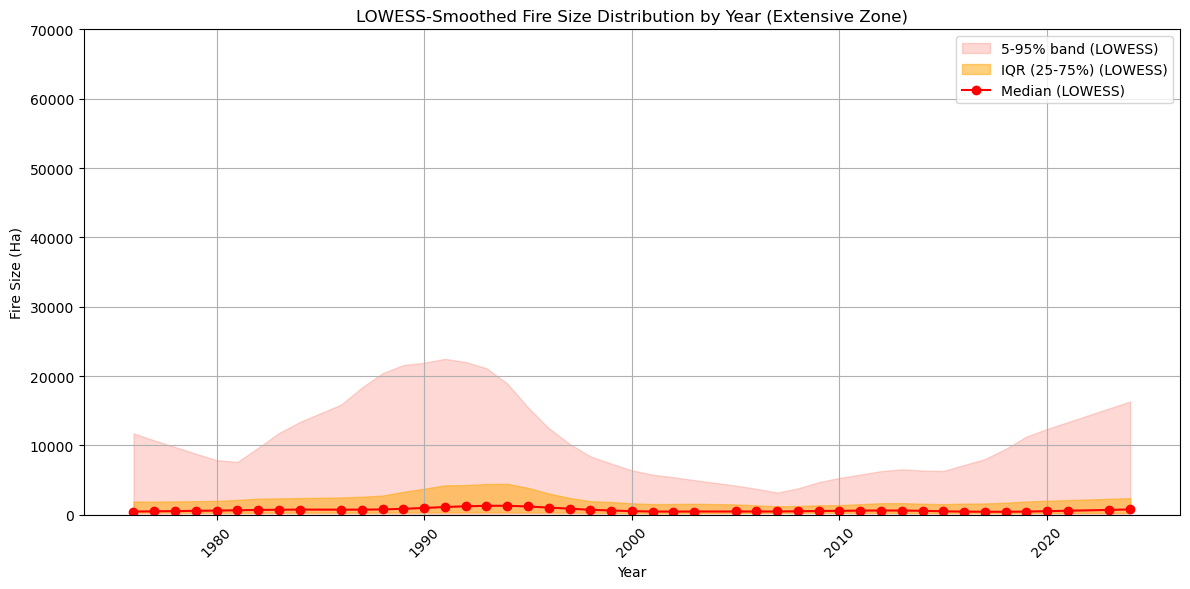

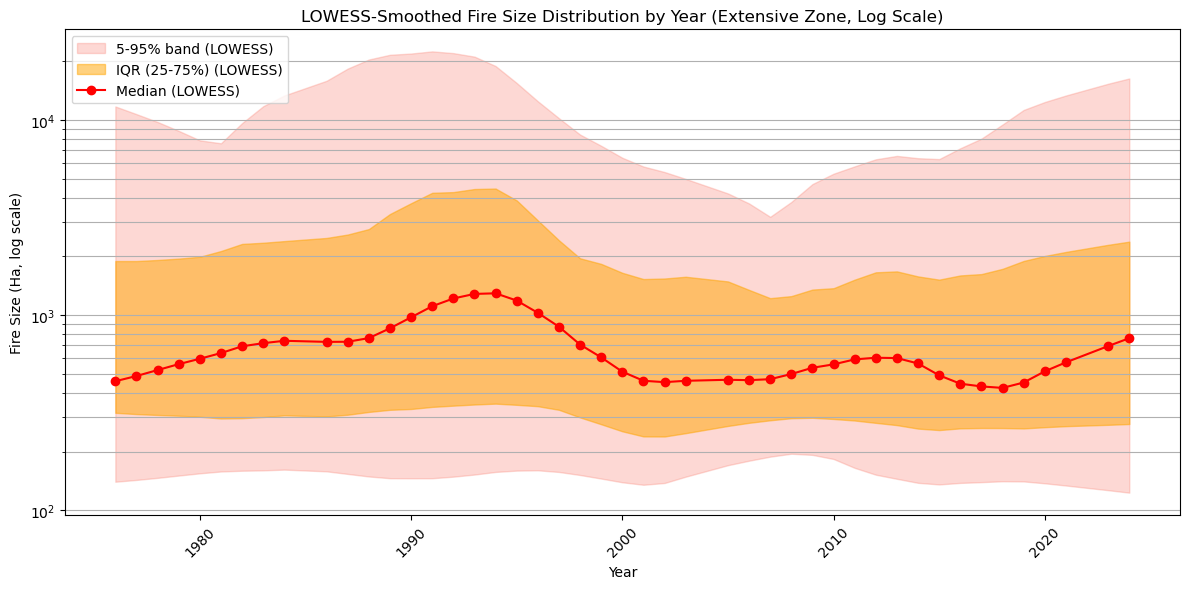

In [25]:
# LOWESS-smoothed 5-95% band, IQR, and median for Intensive Measured Zone (only years with data)
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess

# Group by year and aggregate statistics (only years with data)
stats = extensive.groupby('YEAR')['SIZE_HA'].agg([
    ('median', 'median'),
    ('q25', lambda x: np.percentile(x, 25)),
    ('q75', lambda x: np.percentile(x, 75)),
    ('p5', lambda x: np.percentile(x, 5)),
    ('p95', lambda x: np.percentile(x, 95))
]).reset_index()

x = stats['YEAR'].values
lowess_smooth = {}
frac = 0.25  # Smoothing parameter (adjust as needed)
for col in ['median', 'q25', 'q75', 'p5', 'p95']:
    y = stats[col].values
    smoothed = lowess(y, x, frac=frac, return_sorted=False)
    lowess_smooth[col] = smoothed

plt.figure(figsize=(12, 6))
plt.fill_between(x, lowess_smooth['p5'], lowess_smooth['p95'], color='salmon', alpha=0.3, label='5-95% band (LOWESS)')
plt.fill_between(x, lowess_smooth['q25'], lowess_smooth['q75'], color='orange', alpha=0.5, label='IQR (25-75%) (LOWESS)')
plt.plot(x, lowess_smooth['median'], color='red', marker='o', label='Median (LOWESS)')
plt.title('LOWESS-Smoothed Fire Size Distribution by Year (Extensive Zone)')
plt.xlabel('Year')
plt.ylabel('Fire Size (Ha)')
plt.xticks(rotation=45)
plt.ylim(0, 70000)
plt.grid()
plt.tight_layout()
plt.legend()
plt.show()

# Log scale version
plt.figure(figsize=(12, 6))
plt.fill_between(x, lowess_smooth['p5'], lowess_smooth['p95'], color='salmon', alpha=0.3, label='5-95% band (LOWESS)')
plt.fill_between(x, lowess_smooth['q25'], lowess_smooth['q75'], color='orange', alpha=0.5, label='IQR (25-75%) (LOWESS)')
plt.plot(x, lowess_smooth['median'], color='red', marker='o', label='Median (LOWESS)')
plt.title('LOWESS-Smoothed Fire Size Distribution by Year (Extensive Zone, Log Scale)')
plt.xlabel('Year')
plt.ylabel('Fire Size (Ha, log scale)')
plt.yscale('log')
plt.xticks(rotation=45)
plt.grid(True, which='both', axis='y')
plt.tight_layout()
plt.legend()
plt.show()

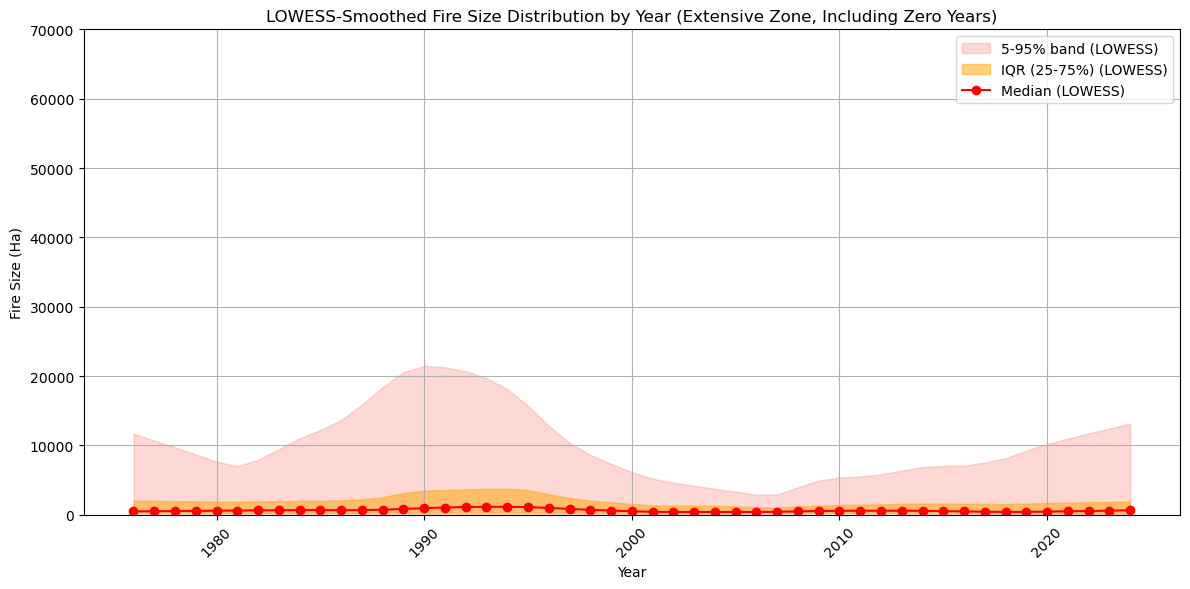

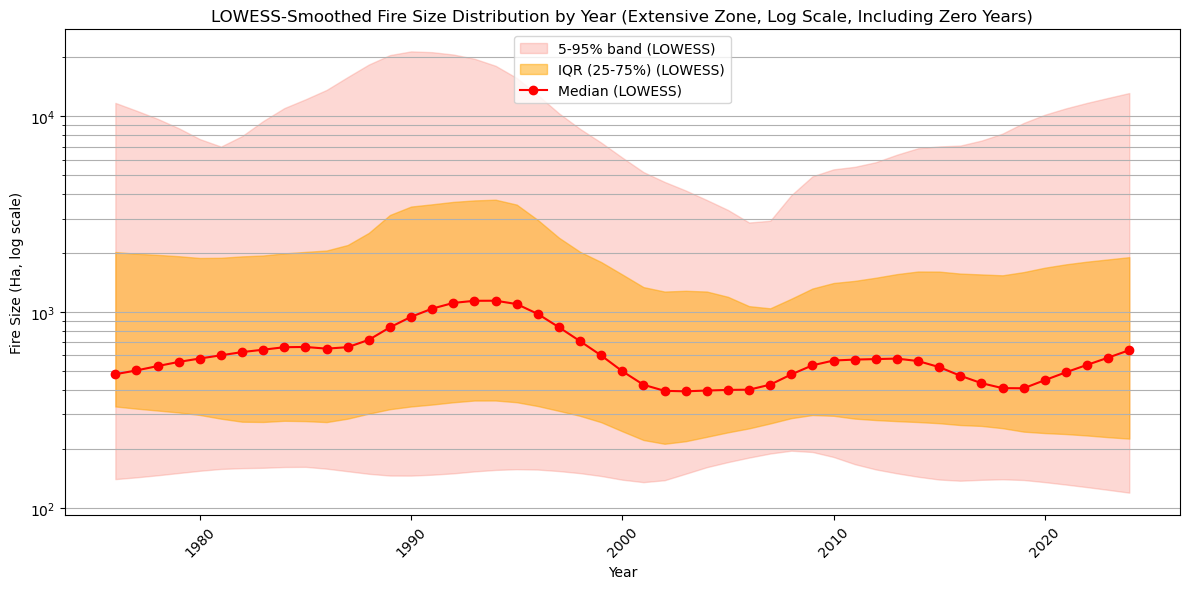

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess

# Group by year and aggregate statistics (include zero years)
stats = extensive.groupby('YEAR')['SIZE_HA'].agg([
    ('median', 'median'),
    ('q25', lambda x: np.percentile(x, 25)),
    ('q75', lambda x: np.percentile(x, 75)),
    ('p5', lambda x: np.percentile(x, 5)),
    ('p95', lambda x: np.percentile(x, 95))
]).reset_index()

# Fill in missing years with zeroes
all_years = np.arange(extensive['YEAR'].min(), extensive['YEAR'].max() + 1)
stats = stats.set_index('YEAR').reindex(all_years).fillna(0).reset_index().rename(columns={'index': 'YEAR'})

x = stats['YEAR'].values
lowess_smooth = {}
frac = 0.25  # Smoothing parameter (adjust as needed)
for col in ['median', 'q25', 'q75', 'p5', 'p95']:
    y = stats[col].values
    smoothed = lowess(y, x, frac=frac, return_sorted=False)
    lowess_smooth[col] = smoothed

plt.figure(figsize=(12, 6))
plt.fill_between(x, lowess_smooth['p5'], lowess_smooth['p95'], color='salmon', alpha=0.3, label='5-95% band (LOWESS)')
plt.fill_between(x, lowess_smooth['q25'], lowess_smooth['q75'], color='orange', alpha=0.5, label='IQR (25-75%) (LOWESS)')
plt.plot(x, lowess_smooth['median'], color='red', marker='o', label='Median (LOWESS)')
plt.title('LOWESS-Smoothed Fire Size Distribution by Year (Extensive Zone, Including Zero Years)')
plt.xlabel('Year')
plt.ylabel('Fire Size (Ha)')
plt.xticks(rotation=45)
plt.ylim(0, 70000)
plt.grid()
plt.tight_layout()
plt.legend()
plt.show()

# Log scale version
plt.figure(figsize=(12, 6))
plt.fill_between(x, lowess_smooth['p5'], lowess_smooth['p95'], color='salmon', alpha=0.3, label='5-95% band (LOWESS)')
plt.fill_between(x, lowess_smooth['q25'], lowess_smooth['q75'], color='orange', alpha=0.5, label='IQR (25-75%) (LOWESS)')
plt.plot(x, lowess_smooth['median'], color='red', marker='o', label='Median (LOWESS)')
plt.title('LOWESS-Smoothed Fire Size Distribution by Year (Extensive Zone, Log Scale, Including Zero Years)')
plt.xlabel('Year')
plt.ylabel('Fire Size (Ha, log scale)')
plt.yscale('log')
plt.xticks(rotation=45)
plt.grid(True, which='both', axis='y')
plt.tight_layout()
plt.legend()
plt.show()

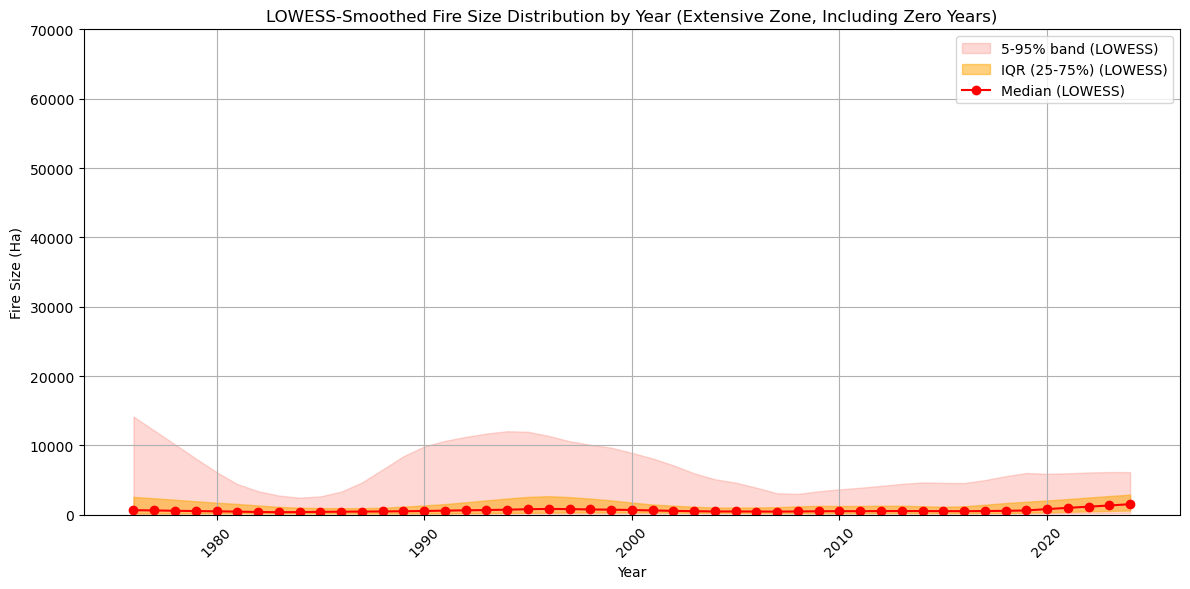

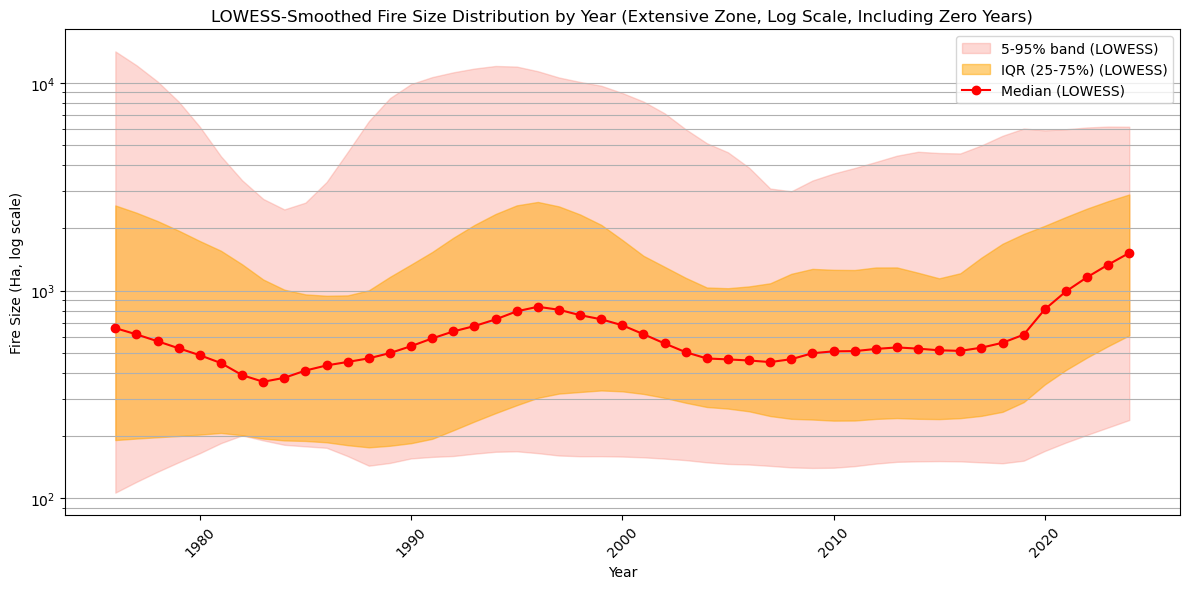

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess

# Group by year and aggregate statistics (include zero years)
stats = intensive.groupby('YEAR')['SIZE_HA'].agg([
    ('median', 'median'),
    ('q25', lambda x: np.percentile(x, 25)),
    ('q75', lambda x: np.percentile(x, 75)),
    ('p5', lambda x: np.percentile(x, 5)),
    ('p95', lambda x: np.percentile(x, 95))
]).reset_index()

# Fill in missing years with zeroes
all_years = np.arange(extensive['YEAR'].min(), extensive['YEAR'].max() + 1)
stats = stats.set_index('YEAR').reindex(all_years).fillna(0).reset_index().rename(columns={'index': 'YEAR'})

x = stats['YEAR'].values
lowess_smooth = {}
frac = 0.25  # Smoothing parameter (adjust as needed)
for col in ['median', 'q25', 'q75', 'p5', 'p95']:
    y = stats[col].values
    smoothed = lowess(y, x, frac=frac, return_sorted=False)
    lowess_smooth[col] = smoothed

plt.figure(figsize=(12, 6))
plt.fill_between(x, lowess_smooth['p5'], lowess_smooth['p95'], color='salmon', alpha=0.3, label='5-95% band (LOWESS)')
plt.fill_between(x, lowess_smooth['q25'], lowess_smooth['q75'], color='orange', alpha=0.5, label='IQR (25-75%) (LOWESS)')
plt.plot(x, lowess_smooth['median'], color='red', marker='o', label='Median (LOWESS)')
plt.title('LOWESS-Smoothed Fire Size Distribution by Year (Extensive Zone, Including Zero Years)')
plt.xlabel('Year')
plt.ylabel('Fire Size (Ha)')
plt.xticks(rotation=45)
plt.ylim(0, 70000)
plt.grid()
plt.tight_layout()
plt.legend()
plt.show()

# Log scale version
plt.figure(figsize=(12, 6))
plt.fill_between(x, lowess_smooth['p5'], lowess_smooth['p95'], color='salmon', alpha=0.3, label='5-95% band (LOWESS)')
plt.fill_between(x, lowess_smooth['q25'], lowess_smooth['q75'], color='orange', alpha=0.5, label='IQR (25-75%) (LOWESS)')
plt.plot(x, lowess_smooth['median'], color='red', marker='o', label='Median (LOWESS)')
plt.title('LOWESS-Smoothed Fire Size Distribution by Year (Extensive Zone, Log Scale, Including Zero Years)')
plt.xlabel('Year')
plt.ylabel('Fire Size (Ha, log scale)')
plt.yscale('log')
plt.xticks(rotation=45)
plt.grid(True, which='both', axis='y')
plt.tight_layout()
plt.legend()
plt.show()

In [29]:
stats

,YEAR,median,q25,q75,p5,p95
0,1976,570.599976,203.825001,3261.399963,117.865002,21347.190137
1,1977,391.299988,149.250004,973.749985,123.655001,6764.319946
2,1978,1250.250000,993.375000,1507.125000,787.875000,1712.625000
3,1979,621.199997,266.050011,3819.200012,131.500004,11826.925049
4,1980,404.700012,202.300003,2432.749939,156.790003,26626.299219
5,1981,283.300003,138.575001,854.924988,114.085000,3512.649957
6,1982,251.900002,246.350002,257.450001,241.910003,261.890000
7,1983,404.700012,161.899994,2565.699951,121.400002,60698.857813
8,1984,566.550003,515.974998,617.125008,475.514995,657.585011
9,1985,0.000000,0.000000,0.000000,0.000000,0.000000


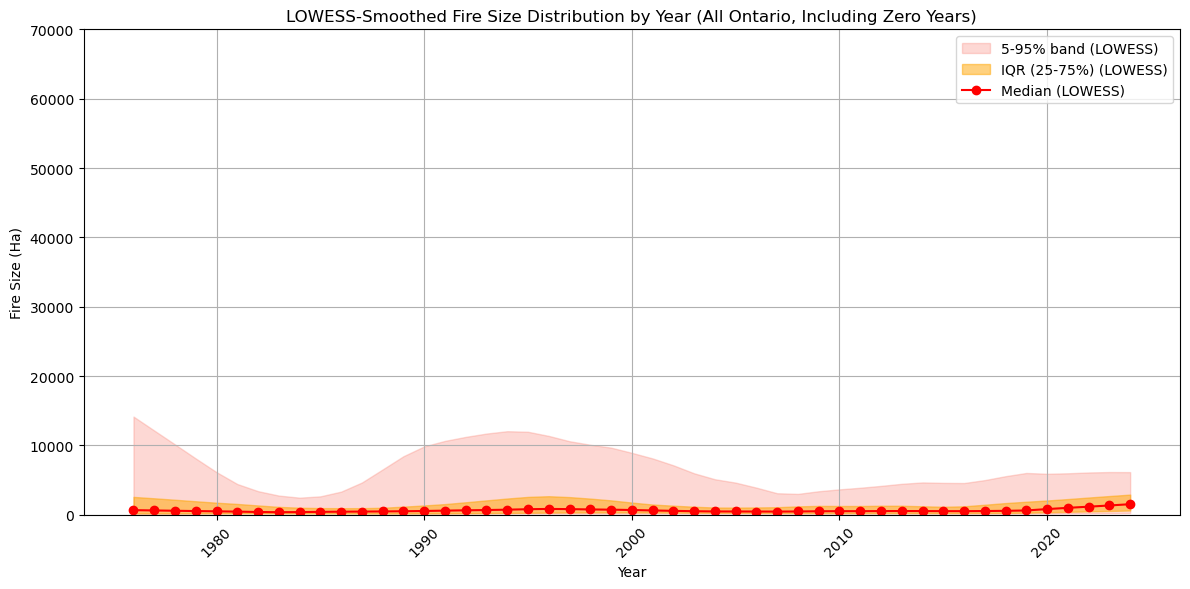

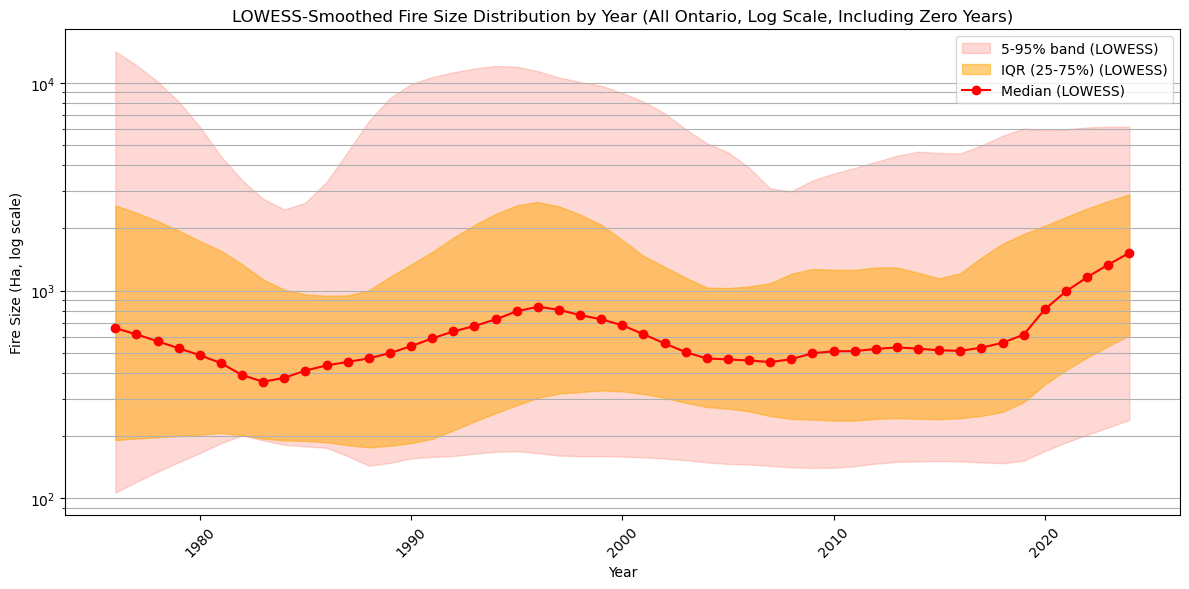

In [82]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess

# Group by year and aggregate statistics (include zero years) for all Ontario (all_fires)
stats = intensive.groupby('YEAR')['SIZE_HA'].agg([
    ('median', 'median'),
    ('q25', lambda x: np.percentile(x, 25)),
    ('q75', lambda x: np.percentile(x, 75)),
    ('p5', lambda x: np.percentile(x, 5)),
    ('p95', lambda x: np.percentile(x, 95))
]).reset_index()

# Fill in missing years with zeroes
all_years = np.arange(all_fires['YEAR'].min(), all_fires['YEAR'].max() + 1)
stats = stats.set_index('YEAR').reindex(all_years).fillna(0).reset_index().rename(columns={'index': 'YEAR'})

x = stats['YEAR'].values
lowess_smooth = {}
frac = 0.25  # Smoothing parameter (adjust as needed)
for col in ['median', 'q25', 'q75', 'p5', 'p95']:
    y = stats[col].values
    smoothed = lowess(y, x, frac=frac, return_sorted=False)
    lowess_smooth[col] = smoothed

plt.figure(figsize=(12, 6))
plt.fill_between(x, lowess_smooth['p5'], lowess_smooth['p95'], color='salmon', alpha=0.3, label='5-95% band (LOWESS)')
plt.fill_between(x, lowess_smooth['q25'], lowess_smooth['q75'], color='orange', alpha=0.5, label='IQR (25-75%) (LOWESS)')
plt.plot(x, lowess_smooth['median'], color='red', marker='o', label='Median (LOWESS)')
plt.title('LOWESS-Smoothed Fire Size Distribution by Year (All Ontario, Including Zero Years)')
plt.xlabel('Year')
plt.ylabel('Fire Size (Ha)')
plt.xticks(rotation=45)
plt.ylim(0, 70000)
plt.grid()
plt.tight_layout()
plt.legend()
plt.show()

# Log scale version
plt.figure(figsize=(12, 6))
plt.fill_between(x, lowess_smooth['p5'], lowess_smooth['p95'], color='salmon', alpha=0.3, label='5-95% band (LOWESS)')
plt.fill_between(x, lowess_smooth['q25'], lowess_smooth['q75'], color='orange', alpha=0.5, label='IQR (25-75%) (LOWESS)')
plt.plot(x, lowess_smooth['median'], color='red', marker='o', label='Median (LOWESS)')
plt.title('LOWESS-Smoothed Fire Size Distribution by Year (All Ontario, Log Scale, Including Zero Years)')
plt.xlabel('Year')
plt.ylabel('Fire Size (Ha, log scale)')
plt.yscale('log')
plt.xticks(rotation=45)
plt.grid(True, which='both', axis='y')
plt.tight_layout()
plt.legend()